# Round 2 EDA
Products: `ASH_COATED_OSMIUM`, `INTARIAN_PEPPER_ROOT`  
3 days of data: day -1, 0, 1

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

DATA = '/Users/markiejr/Propserity_4/data/ROUND2/ROUND_2_DATA'

# Load all 3 days of price data
price_dfs = []
for day in [-1, 0, 1]:
    df = pd.read_csv(f'{DATA}/prices_round_2_day_{day}.csv', sep=';')
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)

# Recompute mid_price cleanly from best bid/ask where available
prices['mid_price_clean'] = np.where(
    prices['bid_price_1'].notna() & prices['ask_price_1'].notna(),
    (prices['bid_price_1'] + prices['ask_price_1']) / 2,
    np.where(prices['bid_price_1'].notna(), prices['bid_price_1'],
    np.where(prices['ask_price_1'].notna(), prices['ask_price_1'], np.nan))
)

# Drop rows with no valid price (both sides empty)
prices = prices[prices['mid_price_clean'].notna() & (prices['mid_price_clean'] > 0)].copy()

# Build a global timestamp (each day = 1_000_000 ticks apart)
prices['global_ts'] = prices['day'].map({-1: 0, 0: 1_000_000, 1: 2_000_000}) + prices['timestamp']

print(f"Rows after cleaning: {prices.shape[0]}")
print(prices.groupby('product')['mid_price_clean'].describe().round(2))
prices.head()

Rows after cleaning: 59900
                        count      mean     std      min      25%      50%  \
product                                                                      
ASH_COATED_OSMIUM     29947.0  10000.88    5.10   9979.0   9998.0  10001.0   
INTARIAN_PEPPER_ROOT  29953.0  12499.92  866.05  10998.0  11750.0  12500.0   

                          75%      max  
product                                 
ASH_COATED_OSMIUM     10004.0  10023.0  
INTARIAN_PEPPER_ROOT  13250.5  14003.0  


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,mid_price_clean,global_ts
0,-1,0,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0,11001.5,0
1,-1,0,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0,9991.0,0
2,-1,100,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0,9992.0,100
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0,11000.0,100
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0,9993.0,200


In [49]:
# Load all 3 days of trade data
trade_dfs = []
for day in [-1, 0, 1]:
    df = pd.read_csv(f'{DATA}/trades_round_2_day_{day}.csv', sep=';')
    df['day'] = day
    trade_dfs.append(df)

trades = pd.concat(trade_dfs, ignore_index=True)
trades['global_ts'] = trades['day'].map({-1: 0, 0: 1_000_000, 1: 2_000_000}) + trades['timestamp']

print(trades.shape)
trades.head()

(2391, 9)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_ts
0,0,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9982.0,6,-1,0
1,3600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,3,-1,3600
2,4200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10002.0,2,-1,4200
3,4400,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11010.0,5,-1,4400
4,5000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10996.0,5,-1,5000


## Mid-Price Over Time

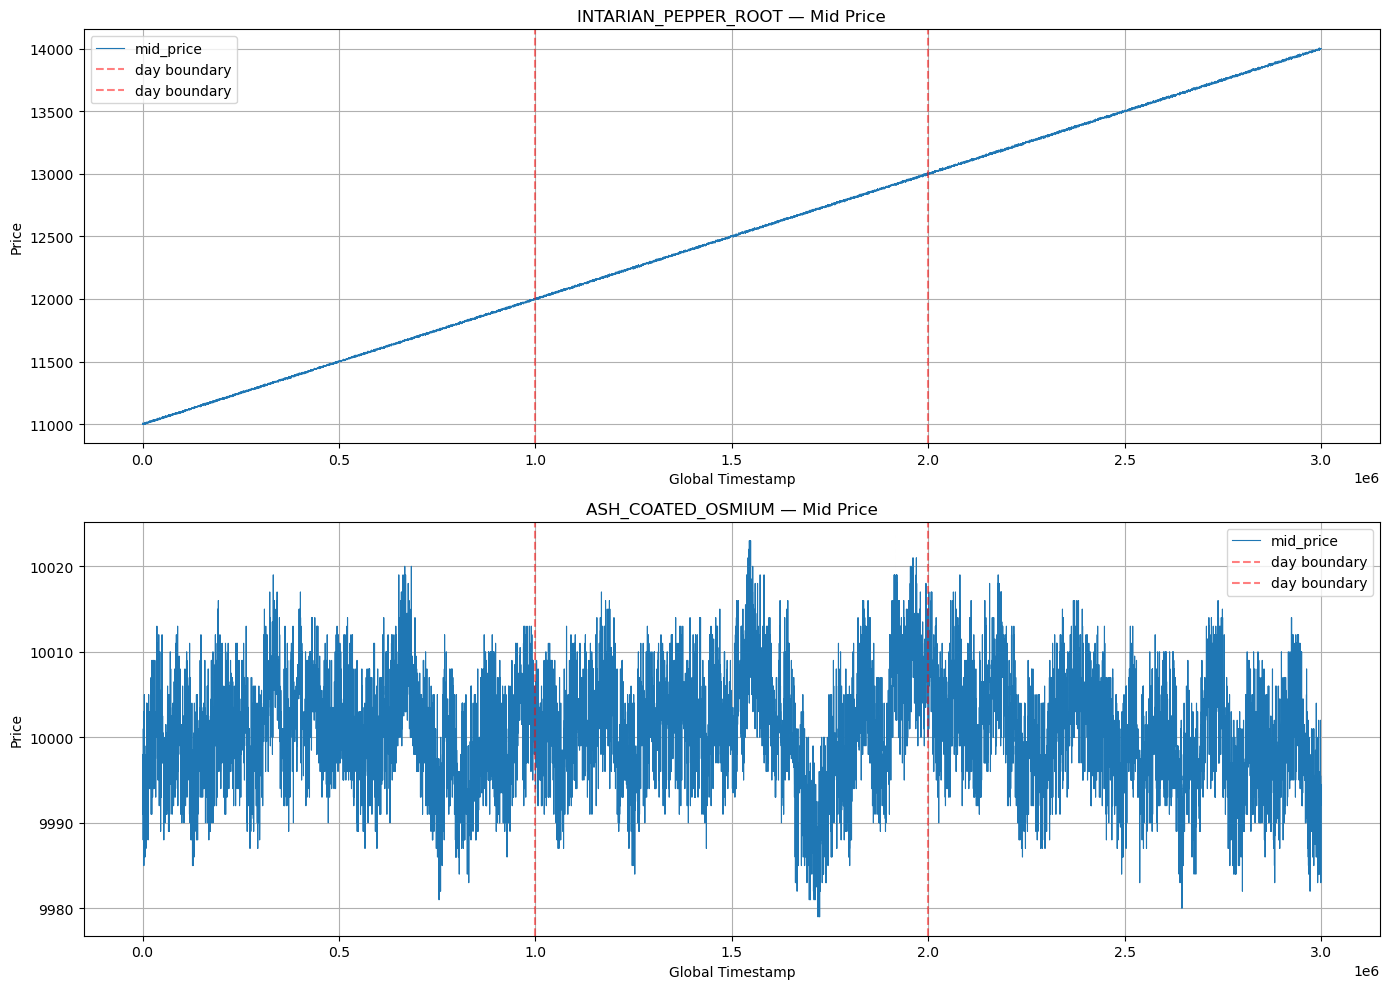

In [50]:
products = prices['product'].unique()

fig, axes = plt.subplots(len(products), 1, figsize=(14, 5 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()
    ax.plot(df['global_ts'], df['mid_price_clean'], linewidth=0.8, label='mid_price')
    
    for day_start in [1_000_000, 2_000_000]:
        ax.axvline(day_start, color='red', linestyle='--', alpha=0.5, label='day boundary')
    
    ax.set_title(f'{product} — Mid Price')
    ax.set_xlabel('Global Timestamp')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.show()

## Rolling Statistics & Z-Score (Mean Reversion Signal)

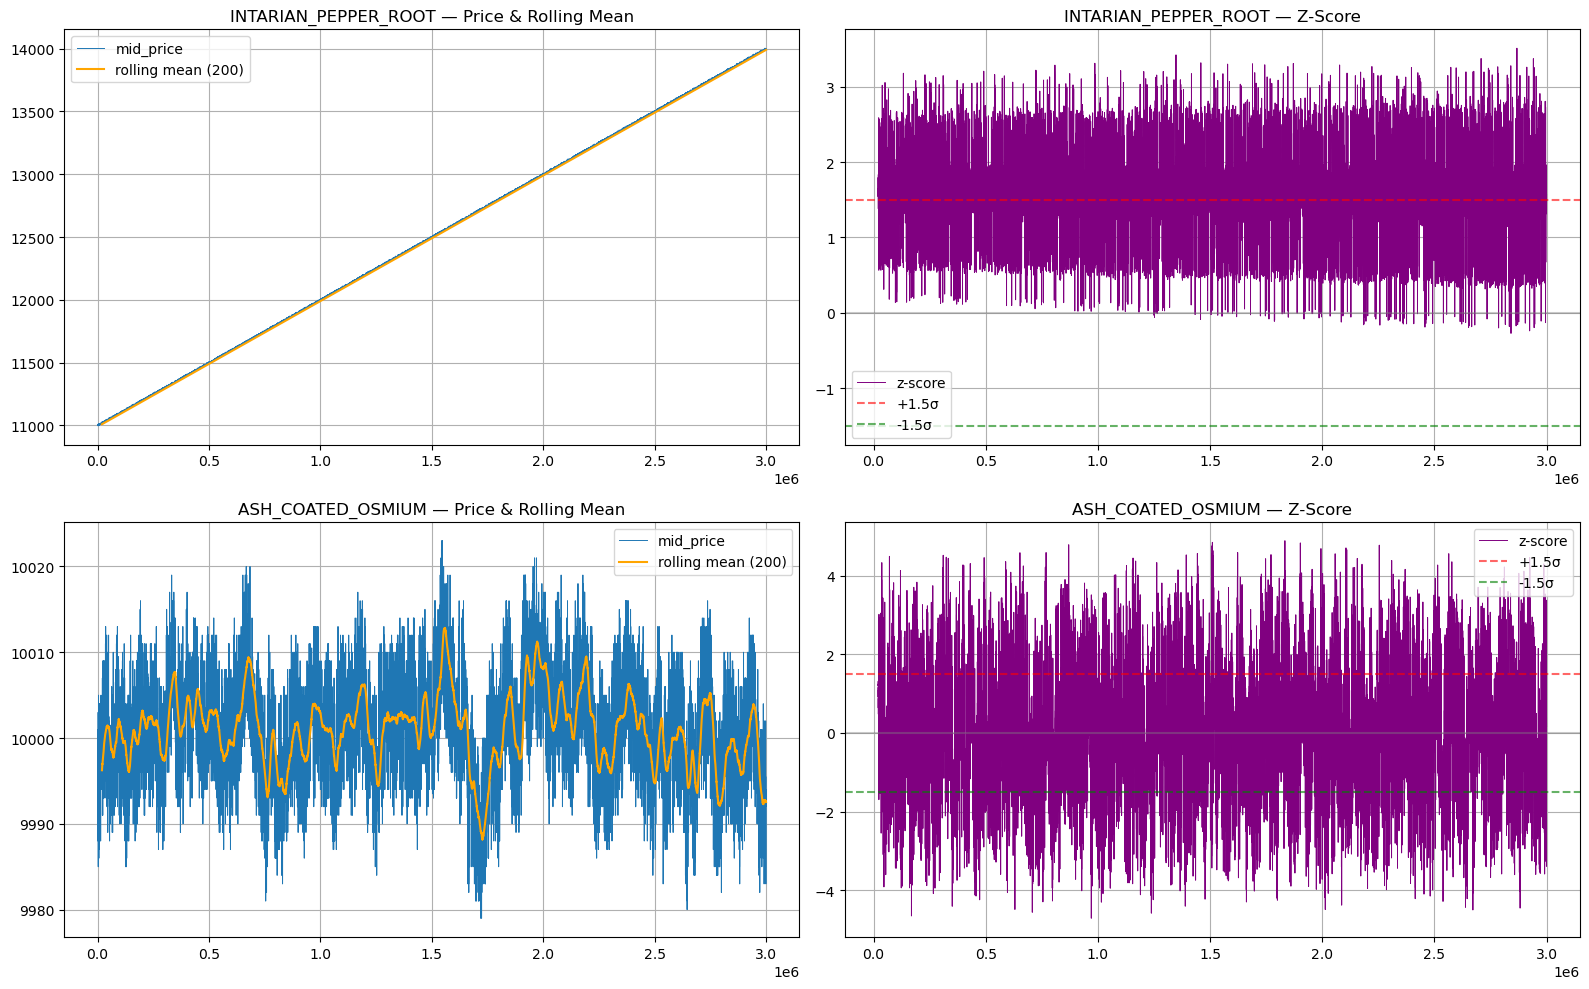

,mean,std,min,max
INTARIAN_PEPPER_ROOT,12499.915785,866.052431,10998.0,14003.0
ASH_COATED_OSMIUM,10000.879420,5.104032,9979.0,10023.0


In [51]:
WINDOW = 200  # ~200 ticks rolling window

fig, axes = plt.subplots(len(products), 2, figsize=(16, 5 * len(products)))
if len(products) == 1:
    axes = [axes]

stats_summary = {}

for i, product in enumerate(products):
    df = prices[prices['product'] == product].copy().reset_index(drop=True)
    
    df['rolling_mean'] = df['mid_price_clean'].rolling(WINDOW).mean()
    df['rolling_std']  = df['mid_price_clean'].rolling(WINDOW).std()
    df['zscore']       = (df['mid_price_clean'] - df['rolling_mean']) / df['rolling_std']

    ax1 = axes[i][0]
    ax1.plot(df['global_ts'], df['mid_price_clean'], linewidth=0.7, label='mid_price')
    ax1.plot(df['global_ts'], df['rolling_mean'], linewidth=1.5, color='orange', label=f'rolling mean ({WINDOW})')
    ax1.set_title(f'{product} — Price & Rolling Mean')
    ax1.legend()

    ax2 = axes[i][1]
    ax2.plot(df['global_ts'], df['zscore'], linewidth=0.7, color='purple', label='z-score')
    ax2.axhline(1.5,  color='red',   linestyle='--', alpha=0.6, label='+1.5σ')
    ax2.axhline(-1.5, color='green', linestyle='--', alpha=0.6, label='-1.5σ')
    ax2.axhline(0,    color='grey',  linestyle='-',  alpha=0.4)
    ax2.set_title(f'{product} — Z-Score')
    ax2.legend()

    stats_summary[product] = {
        'mean': df['mid_price_clean'].mean(),
        'std':  df['mid_price_clean'].std(),
        'min':  df['mid_price_clean'].min(),
        'max':  df['mid_price_clean'].max(),
    }

plt.tight_layout()
plt.show()

pd.DataFrame(stats_summary).T

## Bid-Ask Spread Analysis

INTARIAN_PEPPER_ROOT: mean spread = 14.12, median = 14.00
ASH_COATED_OSMIUM: mean spread = 16.23, median = 16.00


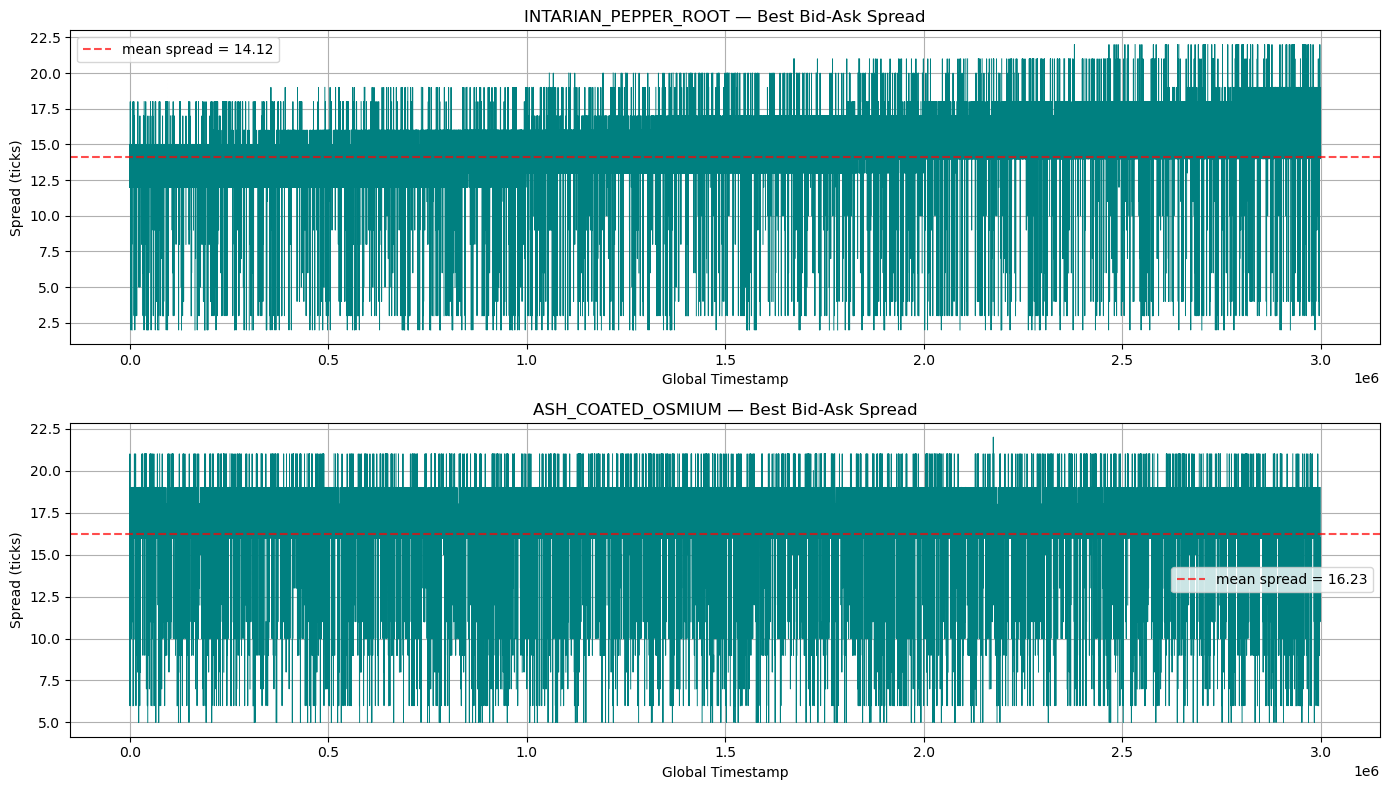

In [52]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()
    df['spread'] = df['ask_price_1'] - df['bid_price_1']
    
    ax.plot(df['global_ts'], df['spread'], linewidth=0.7, color='teal')
    ax.set_title(f'{product} — Best Bid-Ask Spread')
    ax.set_ylabel('Spread (ticks)')
    ax.set_xlabel('Global Timestamp')
    
    mean_spread = df['spread'].mean()
    ax.axhline(mean_spread, color='red', linestyle='--', alpha=0.7, label=f'mean spread = {mean_spread:.2f}')
    ax.legend()
    print(f"{product}: mean spread = {mean_spread:.2f}, median = {df['spread'].median():.2f}")

plt.tight_layout()
plt.show()

## Order Book Imbalance (Buy vs Sell Pressure)

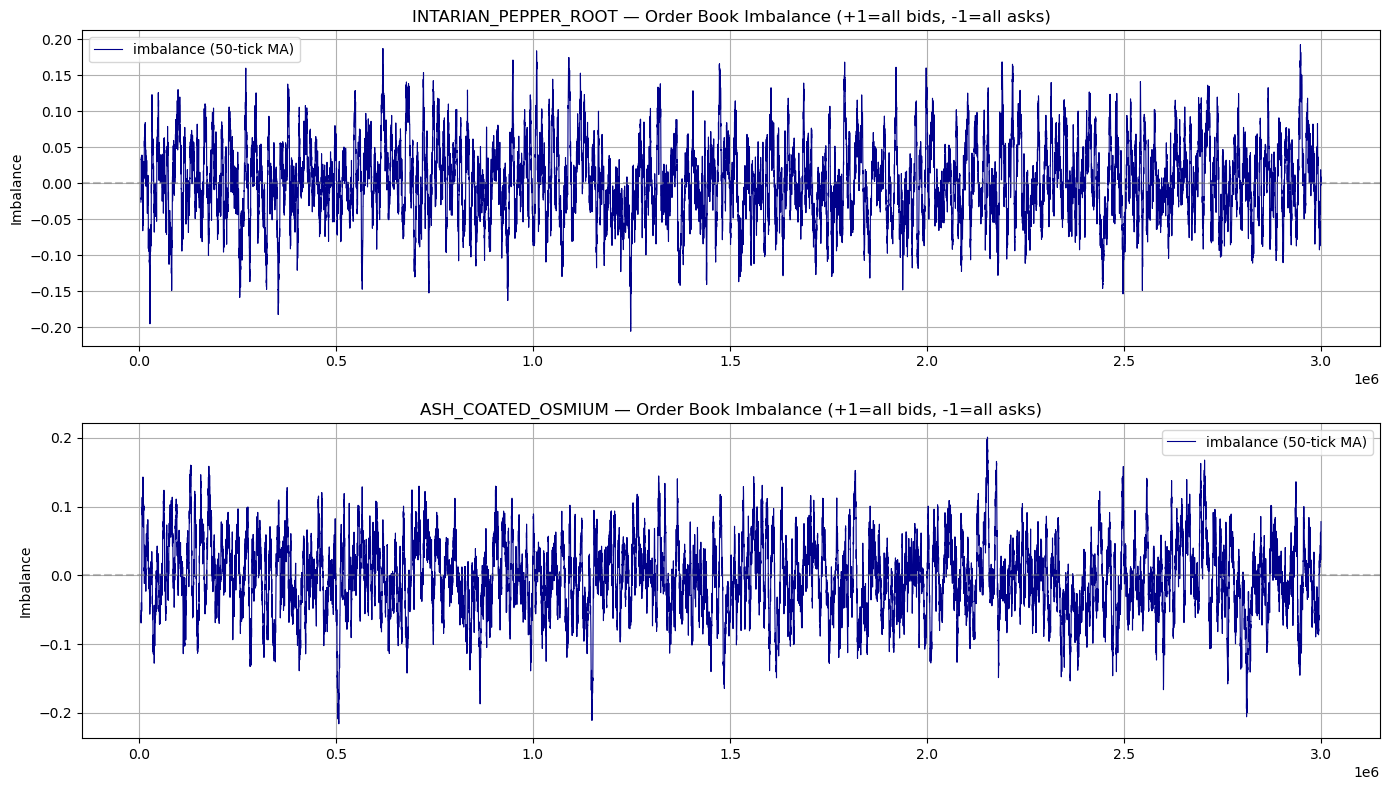

In [53]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    df = prices[prices['product'] == product].copy()

    bid_vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
    ask_vol_cols = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']

    df['total_bid_vol'] = df[bid_vol_cols].fillna(0).sum(axis=1)
    df['total_ask_vol'] = df[ask_vol_cols].fillna(0).sum(axis=1)
    df['imbalance'] = (df['total_bid_vol'] - df['total_ask_vol']) / (df['total_bid_vol'] + df['total_ask_vol'])

    ax.plot(df['global_ts'], df['imbalance'].rolling(50).mean(), linewidth=0.8, color='darkblue', label='imbalance (50-tick MA)')
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(f'{product} — Order Book Imbalance (+1=all bids, -1=all asks)')
    ax.set_ylabel('Imbalance')
    ax.legend()

plt.tight_layout()
plt.show()

## Trade Data Analysis

Trade counts per product:
symbol
ASH_COATED_OSMIUM       1395
INTARIAN_PEPPER_ROOT     996
Name: count, dtype: int64



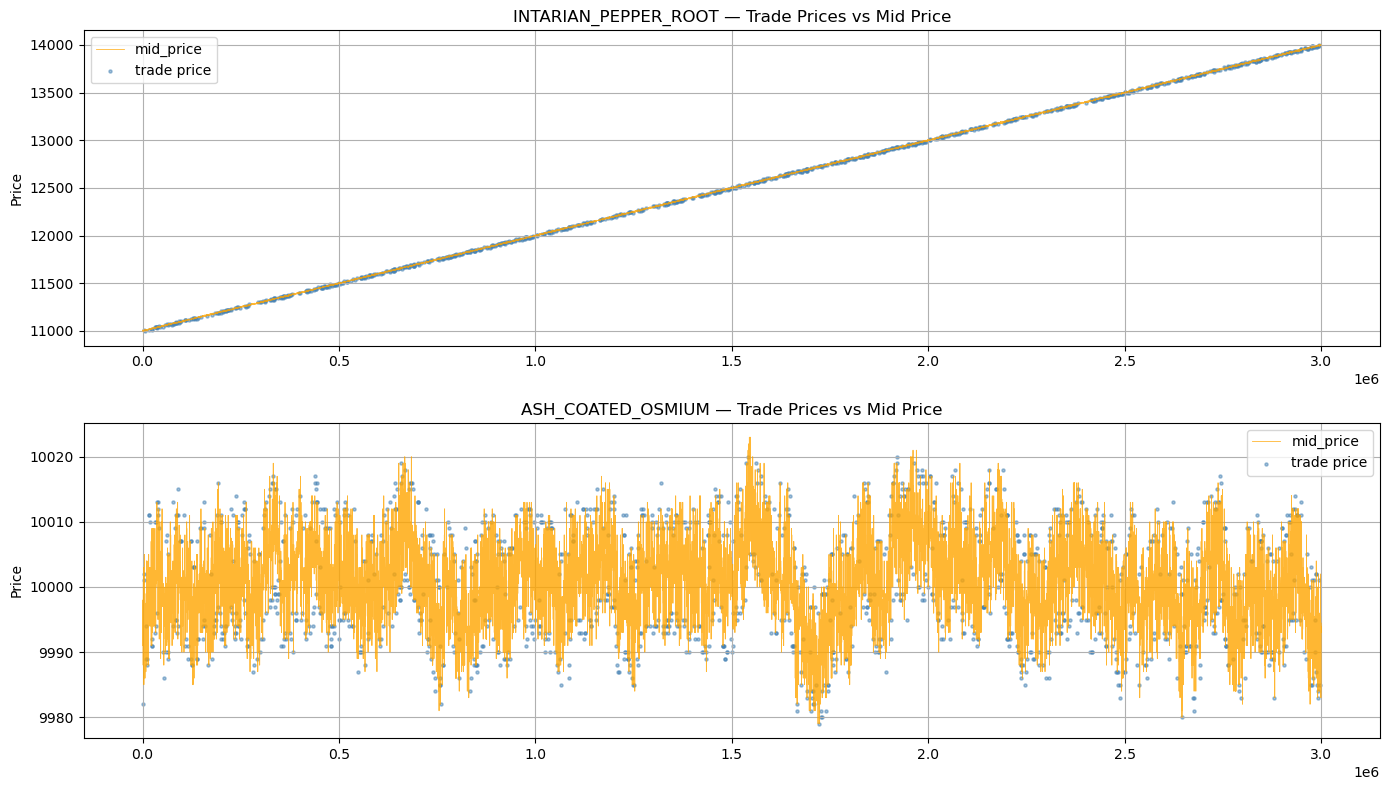

In [54]:
print("Trade counts per product:")
print(trades['symbol'].value_counts())
print()

fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    t = trades[trades['symbol'] == product].copy()
    p = prices[prices['product'] == product]
    
    ax.plot(p['global_ts'], p['mid_price_clean'], linewidth=0.6, color='orange', alpha=0.8, label='mid_price')
    ax.scatter(t['global_ts'], t['price'], s=5, alpha=0.5, color='steelblue', label='trade price')
    
    ax.set_title(f'{product} — Trade Prices vs Mid Price')
    ax.set_ylabel('Price')
    ax.legend()

plt.tight_layout()
plt.show()

## Price Return Distribution (is it normal? fat-tailed?)

INTARIAN_PEPPER_ROOT: mean_return=0.1001, std=3.3394, kurtosis=3.02, lag-1 autocorr=-0.4990
ASH_COATED_OSMIUM: mean_return=0.0001, std=3.6886, kurtosis=3.16, lag-1 autocorr=-0.5011


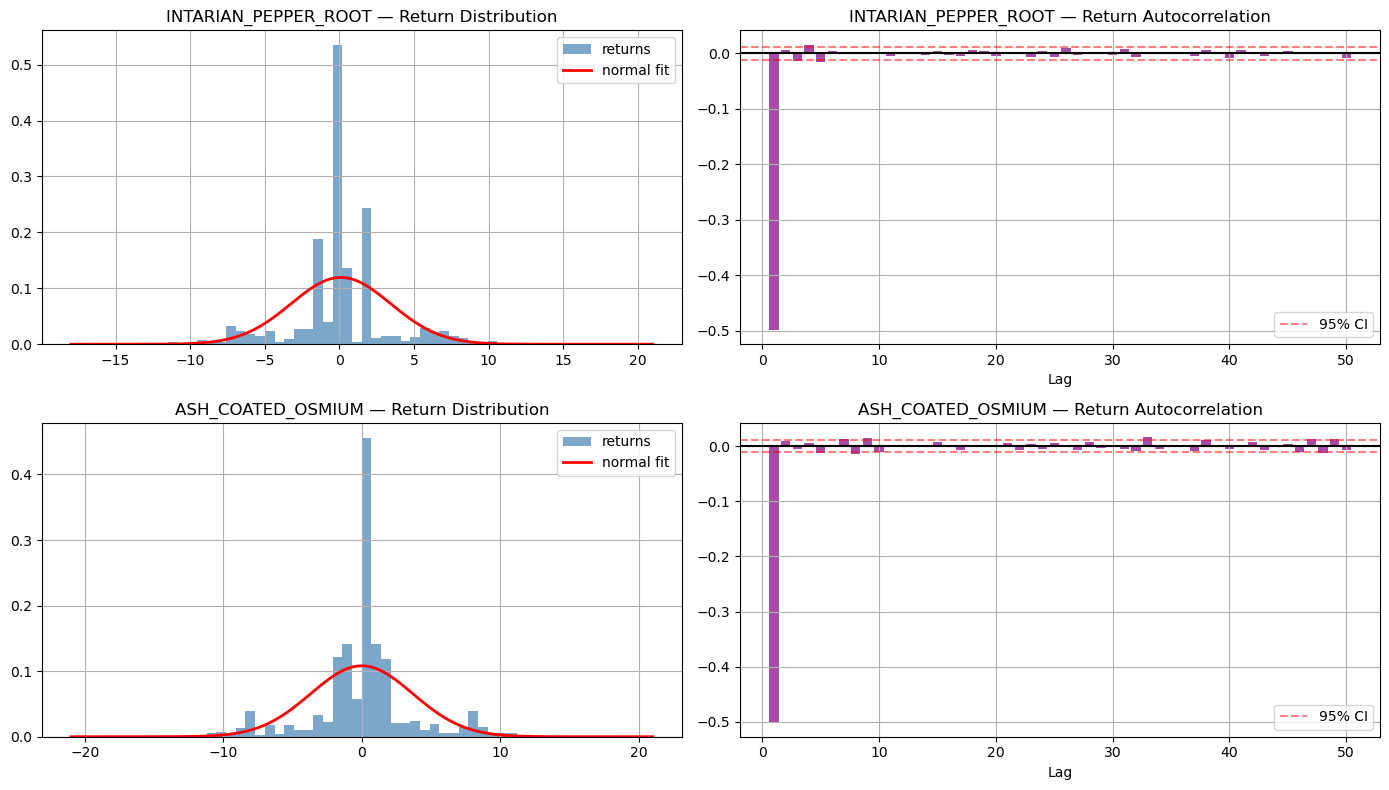

In [55]:
from scipy import stats

fig, axes = plt.subplots(len(products), 2, figsize=(14, 4 * len(products)))
if len(products) == 1:
    axes = [axes]

for i, product in enumerate(products):
    df = prices[prices['product'] == product].copy()
    df['return'] = df['mid_price_clean'].diff()
    returns = df['return'].dropna()

    ax1 = axes[i][0]
    ax1.hist(returns, bins=60, density=True, color='steelblue', alpha=0.7, label='returns')
    xr = np.linspace(returns.min(), returns.max(), 200)
    ax1.plot(xr, stats.norm.pdf(xr, returns.mean(), returns.std()), 'r-', lw=2, label='normal fit')
    ax1.set_title(f'{product} — Return Distribution')
    ax1.legend()

    ax2 = axes[i][1]
    lags = range(1, 51)
    acf_vals = [returns.autocorr(lag=l) for l in lags]
    ax2.bar(lags, acf_vals, color='purple', alpha=0.7)
    ax2.axhline(0, color='black')
    ax2.axhline(1.96/np.sqrt(len(returns)),  color='red', linestyle='--', alpha=0.5, label='95% CI')
    ax2.axhline(-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
    ax2.set_title(f'{product} — Return Autocorrelation')
    ax2.set_xlabel('Lag')
    ax2.legend()
    
    kurt = stats.kurtosis(returns)
    print(f"{product}: mean_return={returns.mean():.4f}, std={returns.std():.4f}, kurtosis={kurt:.2f}, lag-1 autocorr={returns.autocorr(1):.4f}")

plt.tight_layout()
plt.show()

# Custom Backtester
Simulates our algo tick-by-tick against the historical order books.
**Fills modelled:** aggressive orders only (orders that immediately cross the book). Passive quotes that sit in the spread waiting for bots are NOT simulated — so this is a conservative lower-bound on real PnL.
**PnL** = realized cash + unrealized mark-to-market (position × mid-price).

In [56]:
import sys, importlib
sys.path.insert(0, '/Users/markiejr/Propserity_4/scripts/round2')

import round2_algo
importlib.reload(round2_algo)
from round2_algo import Trader

from datamodel import OrderDepth, TradingState, Observation

# ── Helper: build OrderDepth from one CSV row ─────────────────────────────────
def row_to_order_depth(row):
    od = OrderDepth()
    for i in [1, 2, 3]:
        bp, bv = row.get(f'bid_price_{i}', np.nan), row.get(f'bid_volume_{i}', np.nan)
        if pd.notna(bp) and pd.notna(bv) and bp > 0:
            od.buy_orders[int(bp)] = int(bv)
        ap, av = row.get(f'ask_price_{i}', np.nan), row.get(f'ask_volume_{i}', np.nan)
        if pd.notna(ap) and pd.notna(av) and ap > 0:
            od.sell_orders[int(ap)] = -int(av)   # sell_orders are negative
    return od

# ── Helper: execute orders against order book ─────────────────────────────────
def execute_orders(orders_dict, order_depths, position):
    """Match aggressive orders against the book. Returns cash delta."""
    cash_delta = 0.0
    for product, orders in orders_dict.items():
        od = order_depths.get(product)
        if od is None:
            continue
        sell_avail = {p: -q for p, q in od.sell_orders.items()}  # positive qty
        buy_avail  = dict(od.buy_orders)
        pos = position.get(product, 0)

        for order in orders:
            qty = order.quantity   # positive = buy, negative = sell

            if qty > 0:   # BUY: sweep asks ≤ order.price
                for ask_price in sorted(sell_avail.keys()):
                    if ask_price > order.price or qty <= 0:
                        break
                    fill = min(qty, sell_avail[ask_price])
                    pos += fill
                    cash_delta -= fill * ask_price
                    sell_avail[ask_price] -= fill
                    qty -= fill

            elif qty < 0:  # SELL: sweep bids ≥ order.price
                sell_qty = -qty
                for bid_price in sorted(buy_avail.keys(), reverse=True):
                    if bid_price < order.price or sell_qty <= 0:
                        break
                    fill = min(sell_qty, buy_avail[bid_price])
                    pos -= fill
                    cash_delta += fill * bid_price
                    buy_avail[bid_price] -= fill
                    sell_qty -= fill

        position[product] = pos
    return cash_delta

print("Helper functions defined.")

Helper functions defined.


In [57]:
DAY_OFFSET = {-1: 0, 0: 1_000_000, 1: 2_000_000}

def run_backtest(prices_df):
    trader      = Trader()
    position    = {}
    cash        = 0.0
    trader_data = ""
    last_mid    = {}   # last known mid price for EVERY product — fixes missing-tick spikes
    records     = []

    for (day, timestamp), group in prices_df.groupby(['day', 'timestamp']):
        # Build order depths and update last known mid prices
        order_depths = {}
        for _, row in group.iterrows():
            product = row['product']
            order_depths[product] = row_to_order_depth(row)
            last_mid[product]     = row['mid_price_clean']   # always update

        state = TradingState(
            traderData    = trader_data,
            timestamp     = int(timestamp),
            listings      = {},
            order_depths  = order_depths,
            own_trades    = {},
            market_trades = {},
            position      = {p: position.get(p, 0) for p in order_depths},
            observations  = Observation({}, {})
        )

        result, _, trader_data = trader.run(state)
        cash += execute_orders(result, order_depths, position)

        # Mark-to-market using last known mid for ALL products (not just this tick's)
        unrealized = sum(position.get(p, 0) * last_mid[p] for p in last_mid)

        records.append({
            'global_ts' : DAY_OFFSET[day] + timestamp,
            'day'       : day,
            'timestamp' : timestamp,
            'cash'      : cash,
            'unrealized': unrealized,
            'total_pnl' : cash + unrealized,
            'pos_ipr'   : position.get('INTARIAN_PEPPER_ROOT', 0),
            'pos_osm'   : position.get('ASH_COATED_OSMIUM', 0),
        })

    return pd.DataFrame(records)

print("Running backtest over 3 days...")
bt = run_backtest(prices)
print(f"Done. Final PnL: {bt['total_pnl'].iloc[-1]:,.2f} XIRECs")
bt.tail()

Running backtest over 3 days...
Done. Final PnL: 239,291.00 XIRECs


,global_ts,day,timestamp,cash,unrealized,total_pnl,pos_ipr,pos_osm
29995,2999500,1,999500,-880669.0,1119840.0,239171.0,80,0
29996,2999600,1,999600,-880669.0,1119960.0,239291.0,80,0
29997,2999700,1,999700,-880669.0,1119960.0,239291.0,80,0
29998,2999800,1,999800,-880669.0,1119960.0,239291.0,80,0
29999,2999900,1,999900,-880669.0,1119960.0,239291.0,80,0


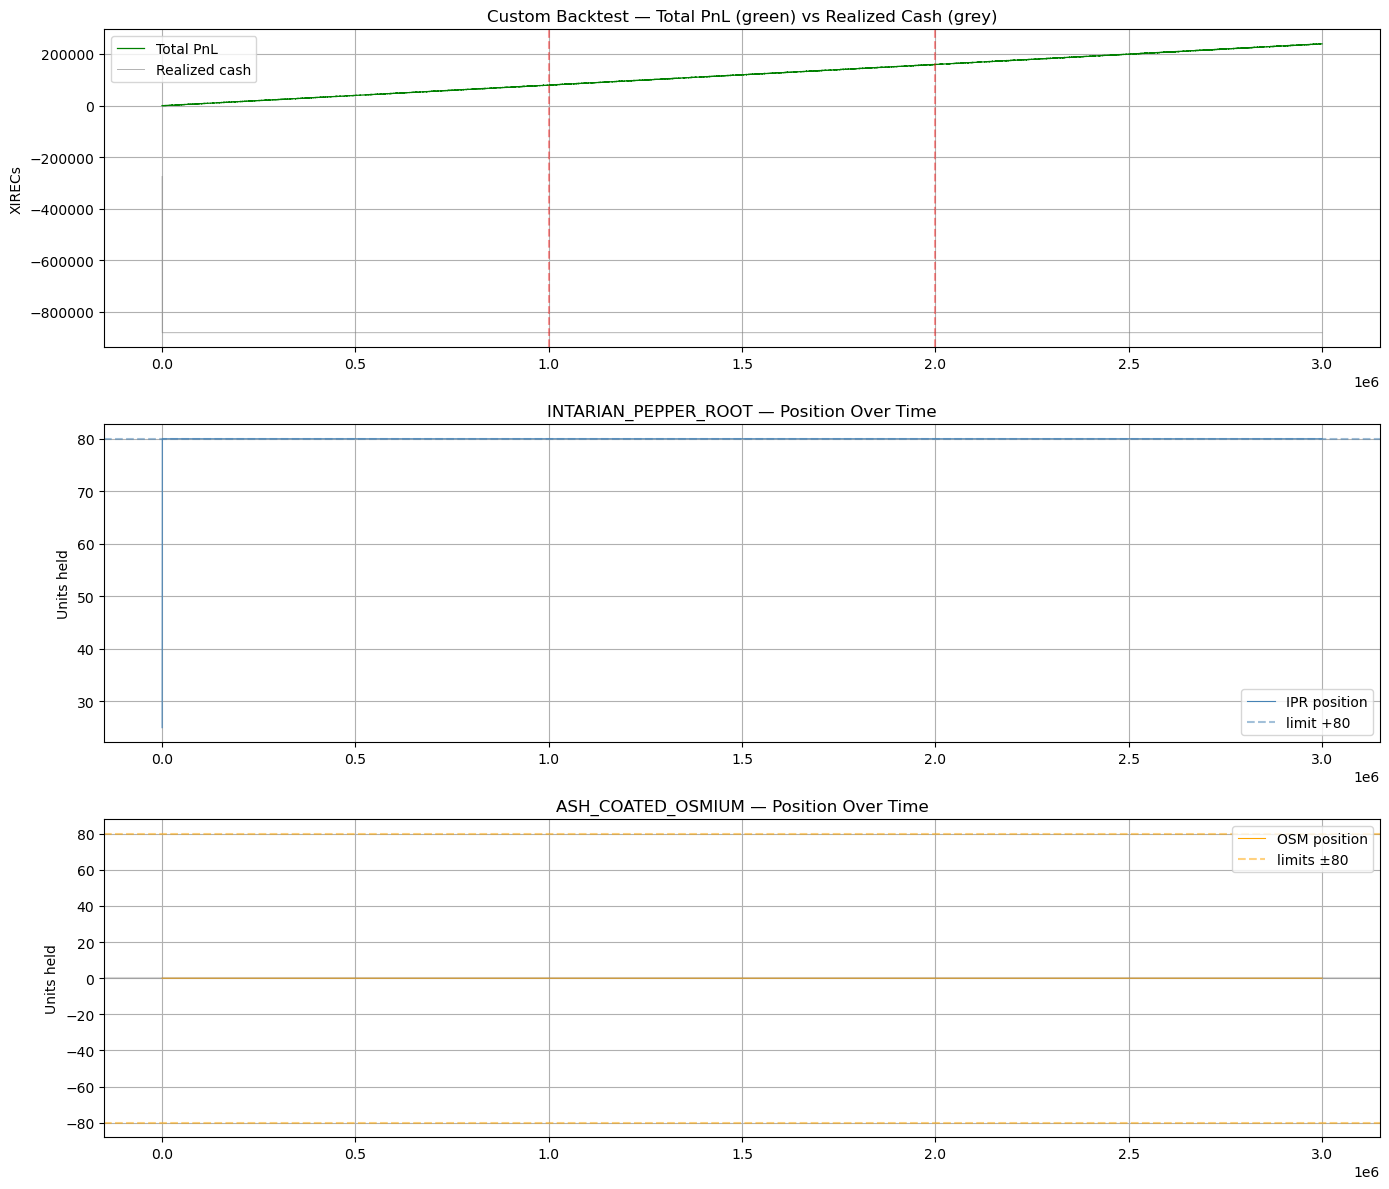

  CUSTOM BACKTEST SUMMARY (3 days)
  Final total PnL :   239,291.00
  Final cash      :  -880,669.00
  Final IPR pos   :           80
  Final OSM pos   :            0
  Max drawdown    :    -1,680.00


In [58]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Total PnL ─────────────────────────────────────────────────────────────────
axes[0].plot(bt['global_ts'], bt['total_pnl'], color='green', linewidth=0.9, label='Total PnL')
axes[0].plot(bt['global_ts'], bt['cash'],      color='grey',  linewidth=0.7, alpha=0.6, label='Realized cash')
for d in [1_000_000, 2_000_000]:
    axes[0].axvline(d, color='red', linestyle='--', alpha=0.4)
axes[0].set_title('Custom Backtest — Total PnL (green) vs Realized Cash (grey)')
axes[0].set_ylabel('XIRECs')
axes[0].legend()

# ── Positions ─────────────────────────────────────────────────────────────────
axes[1].plot(bt['global_ts'], bt['pos_ipr'], color='steelblue', linewidth=0.8, label='IPR position')
axes[1].axhline(80,  color='steelblue', linestyle='--', alpha=0.5, label='limit +80')
axes[1].set_title('INTARIAN_PEPPER_ROOT — Position Over Time')
axes[1].set_ylabel('Units held')
axes[1].legend()

axes[2].plot(bt['global_ts'], bt['pos_osm'], color='orange', linewidth=0.8, label='OSM position')
axes[2].axhline( 80, color='orange', linestyle='--', alpha=0.5)
axes[2].axhline(-80, color='orange', linestyle='--', alpha=0.5, label='limits ±80')
axes[2].axhline(0,   color='grey',   linestyle='-',  alpha=0.3)
axes[2].set_title('ASH_COATED_OSMIUM — Position Over Time')
axes[2].set_ylabel('Units held')
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats
print(f"{'='*40}")
print(f"  CUSTOM BACKTEST SUMMARY (3 days)")
print(f"{'='*40}")
print(f"  Final total PnL : {bt['total_pnl'].iloc[-1]:>12,.2f}")
print(f"  Final cash      : {bt['cash'].iloc[-1]:>12,.2f}")
print(f"  Final IPR pos   : {bt['pos_ipr'].iloc[-1]:>12}")
print(f"  Final OSM pos   : {bt['pos_osm'].iloc[-1]:>12}")
print(f"  Max drawdown    : {(bt['total_pnl'] - bt['total_pnl'].cummax()).min():>12,.2f}")
print(f"{'='*40}")

# prosperity2bt Backtest
Community-built backtester that more closely replicates the Prosperity platform's simulation, including passive order fills. Install with: `pip install prosperity2bt`

In [59]:
import subprocess
result = subprocess.run(['pip', 'install', 'prosperity2bt', '-q'], capture_output=True, text=True)
print(result.stdout or "Already installed.")
print(result.stderr[:300] if result.stderr else "")

Already installed.



In [60]:
from prosperity2bt.file_reader import FileSystemReader, FileReader
from prosperity2bt.runner import run_backtest as p2bt_run
from prosperity2bt.__main__ import parse_algorithm
import prosperity2bt.data as p2bt_data
from pathlib import Path

p2bt_data.LIMITS['ASH_COATED_OSMIUM']      = 80
p2bt_data.LIMITS['INTARIAN_PEPPER_ROOT']   = 80

# p2bt expects `{root}/round2/prices_round_2_day_X.csv`. Our layout is
# `data/ROUND2/ROUND_2_DATA/prices_round_2_day_X.csv`. Custom reader remaps.
class RemappedReader(FileReader):
    def __init__(self, base: Path):
        self._base = base
    def file(self, parts):
        folder, filename = parts[0], parts[1]
        n = folder.replace('round', '')
        candidate = self._base / f'ROUND{n}' / f'ROUND_{n}_DATA' / filename
        from prosperity2bt.file_reader import wrap_in_context_manager
        return wrap_in_context_manager(candidate if candidate.is_file() else None)

DATA_ROOT = Path('/Users/markiejr/Propserity_4/data')
ALGO_PATH = '/Users/markiejr/Propserity_4/scripts/round2/round2_algo.py'

algo_module = parse_algorithm(ALGO_PATH)
trader      = algo_module.Trader()
file_reader = RemappedReader(DATA_ROOT)

p2bt_results = []
for day in [-1, 0, 1]:
    res = p2bt_run(
        trader, file_reader,
        round_num=2, day_num=day,
        print_output=False, disable_trades_matching=False,
        no_names=False, show_progress_bar=False,
    )
    last_ts   = res.activity_logs[-1].timestamp
    final_pnl = sum(row.columns[-1] for row in res.activity_logs if row.timestamp == last_ts)
    p2bt_results.append((day, res, final_pnl))
    print(f"Day {day:+d}: PnL = {final_pnl:,.2f} XIRECs  ({len(res.activity_logs)} log rows)")

Day -1: PnL = 79,291.00 XIRECs  (20000 log rows)
Day +0: PnL = 79,285.00 XIRECs  (20000 log rows)
Day +1: PnL = 79,211.00 XIRECs  (20000 log rows)


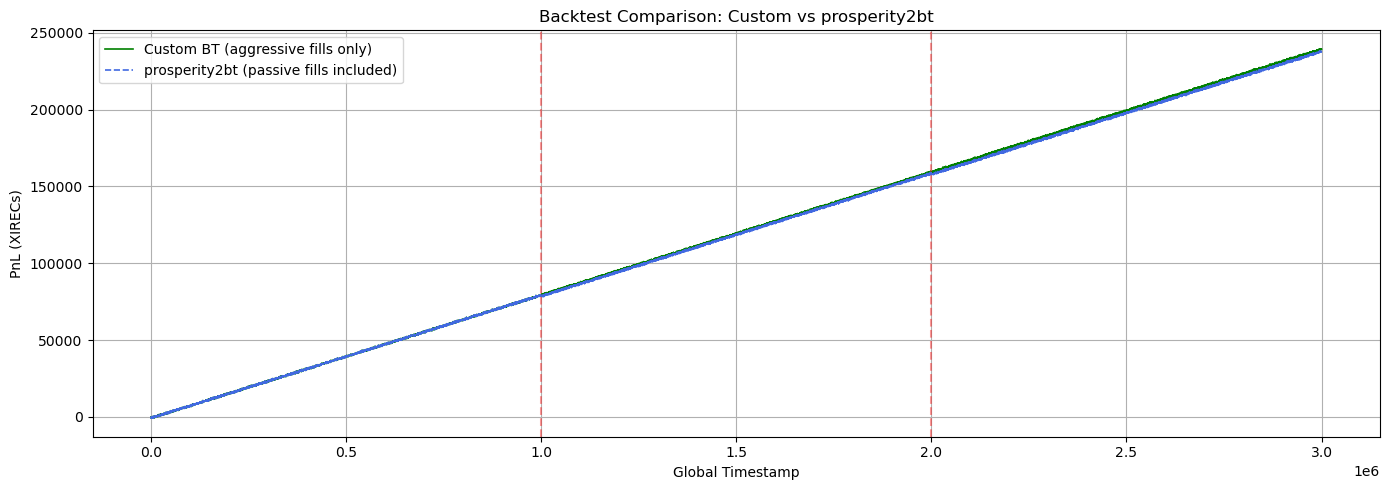


Metric                               Custom BT   prosperity2bt
--------------------------------------------------------------
Total PnL (3 days)                  239,291.00      237,787.00

Passive fill contribution: -1,504.00 XIRECs


In [61]:
fig, ax = plt.subplots(figsize=(14, 5))

# Custom backtest line
ax.plot(bt['global_ts'], bt['total_pnl'], color='green', linewidth=1.2, label='Custom BT (aggressive fills only)')

# prosperity2bt — stitch PnL across days
# Fix: only update a product's PnL when its mid_price is non-zero.
# At ticks where IPR has no order book, p2bt sets mid=0 → PnL = cash only = -800k.
# We skip those rows (same idea as last_mid in custom BT).
p2bt_ts_all, p2bt_pnl_all = [], []
pnl_offset = 0.0

for day, res, final_pnl in p2bt_results:
    ts_offset = DAY_OFFSET[day]

    last_pnl_by_product = {}
    pnl_by_ts = {}

    for row in res.activity_logs:
        product  = row.columns[2]
        mid      = row.columns[-2]
        pnl      = row.columns[-1]
        # Only trust the PnL when mid_price is valid (non-zero, non-empty)
        if mid and mid != '' and float(mid) > 0:
            last_pnl_by_product[product] = pnl
        if last_pnl_by_product:
            pnl_by_ts[row.timestamp] = sum(last_pnl_by_product.values())

    for ts in sorted(pnl_by_ts):
        p2bt_ts_all.append(ts_offset + ts)
        p2bt_pnl_all.append(pnl_by_ts[ts] + pnl_offset)

    pnl_offset += final_pnl

ax.plot(p2bt_ts_all, p2bt_pnl_all, color='royalblue', linewidth=1.2,
        linestyle='--', label='prosperity2bt (passive fills included)')

for d in [1_000_000, 2_000_000]:
    ax.axvline(d, color='red', linestyle='--', alpha=0.4)

ax.set_title('Backtest Comparison: Custom vs prosperity2bt')
ax.set_ylabel('PnL (XIRECs)')
ax.set_xlabel('Global Timestamp')
ax.legend()
plt.tight_layout()
plt.show()

# Summary
custom_final = bt['total_pnl'].iloc[-1]
p2bt_total   = sum(fpnl for _, _, fpnl in p2bt_results)

print(f"\n{'Metric':<30} {'Custom BT':>15} {'prosperity2bt':>15}")
print('-' * 62)
print(f"{'Total PnL (3 days)':<30} {custom_final:>15,.2f} {p2bt_total:>15,.2f}")
print(f"\nPassive fill contribution: {p2bt_total - custom_final:>+,.2f} XIRECs")

# Round 1 Live Log Deep Dive — Submission 269252Live run of our Round 1 algo on day 1 (the actual scoring day).  **Final PnL: 81,077.78 XIRECs.** Submitted algo is byte-identical to `round1_algo.py` (and therefore to `round2_algo.py`).Goal: understand exactly where the PnL came from, where we got adversely selected, and where the algo leaked edge.

In [62]:
import json
from io import StringIO

LOG_PATH  = '/Users/markiejr/Propserity_4/data/ROUND2/ROUND_2_LOGS/269252.log'
JSON_PATH = '/Users/markiejr/Propserity_4/data/ROUND2/ROUND_2_LOGS/269252.json'

with open(LOG_PATH)  as f: log  = json.load(f)
with open(JSON_PATH) as f: meta = json.load(f)

# activitiesLog — one row per (product, timestamp)
act_live = pd.read_csv(StringIO(log['activitiesLog']), sep=';')
act_live_clean = act_live[act_live['mid_price'] > 0].copy()

# tradeHistory — 877 trades total (mix of market trades + ours)
trades_live = pd.DataFrame(log['tradeHistory'])
our = trades_live[(trades_live['buyer']=='SUBMISSION') | (trades_live['seller']=='SUBMISSION')].copy()
our['side'] = np.where(our['buyer']=='SUBMISSION','BUY','SELL')

# graphLog — official PnL sampled every 2000 ticks
graph = pd.read_csv(StringIO(meta['graphLog']), sep=';')

# Basic summary
print(f"activitiesLog rows: {len(act_live):,}  (clean: {len(act_live_clean):,})")
print(f"Total trades in history: {len(trades_live):,}")
print(f"Our trades (SUBMISSION): {len(our):,}  —  BUY: {(our['side']=='BUY').sum()}, SELL: {(our['side']=='SELL').sum()}")
print(f"\nFinal positions: {meta['positions']}")
print(f"Reported profit: {meta['profit']:,.2f} XIRECs")

activitiesLog rows: 20,000  (clean: 19,964)
Total trades in history: 877
Our trades (SUBMISSION): 482  —  BUY: 246, SELL: 236

Final positions: [{'symbol': 'XIRECS', 'quantity': -1358700}, {'symbol': 'INTARIAN_PEPPER_ROOT', 'quantity': 80}, {'symbol': 'ASH_COATED_OSMIUM', 'quantity': 32}]
Reported profit: 81,077.78 XIRECs


## PnL Attribution by Product

In [63]:
# Per-product PnL at final tick (from activitiesLog's profit_and_loss column)
last_ts = act_live['timestamp'].max()
final_pnl = act_live[act_live['timestamp']==last_ts][['product','profit_and_loss','mid_price']].copy()
final_pnl.columns = ['product','final_pnl','final_mid']
print(final_pnl.to_string(index=False))
print(f"\nSum: {final_pnl['final_pnl'].sum():,.2f}  (reported: {meta['profit']:,.2f})")

# Per-product trade stats
print("\n=== Trade stats per product ===")
for sym in our['symbol'].unique():
    sub = our[our['symbol']==sym]
    bought = sub[sub['side']=='BUY']['quantity'].sum()
    sold   = sub[sub['side']=='SELL']['quantity'].sum()
    cash   = (sub['quantity'] * np.where(sub['side']=='BUY', -sub['price'], sub['price'])).sum()
    print(f"  {sym}: {len(sub):>4} trades | bought {bought:>4} | sold {sold:>4} | net_pos {bought-sold:+d} | net_cash {cash:+,.0f}")

             product   final_pnl  final_mid
   ASH_COATED_OSMIUM  1822.78125    10001.0
INTARIAN_PEPPER_ROOT 79255.00000    13999.5

Sum: 81,077.78  (reported: 81,077.78)

=== Trade stats per product ===
  INTARIAN_PEPPER_ROOT:    5 trades | bought   80 | sold    0 | net_pos +80 | net_cash -1,040,737
  ASH_COATED_OSMIUM:  477 trades | bought 1264 | sold 1232 | net_pos +32 | net_cash -317,963


## PnL Curve & Positions Over Time

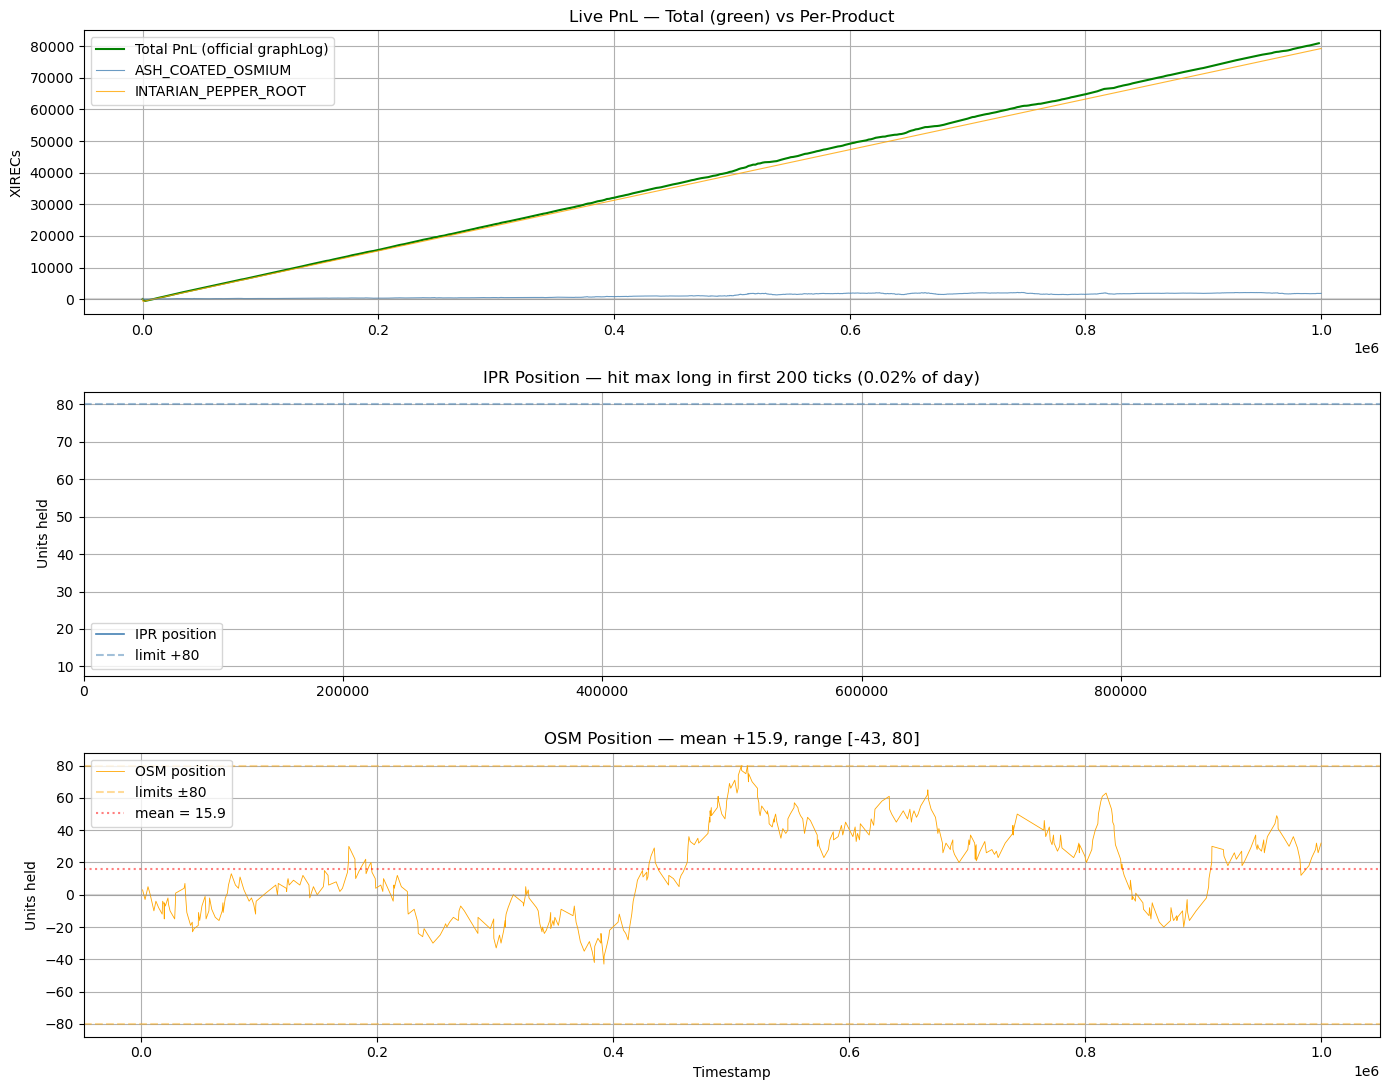


OSM position distribution: mean +15.9, std 27.3
  Ticks at +80: 2 | at -80: 0 | at 0: 6


In [64]:
# Reconstruct position-over-time from trades
our_sorted = our.sort_values('timestamp').reset_index(drop=True)
pos = {'INTARIAN_PEPPER_ROOT': 0, 'ASH_COATED_OSMIUM': 0}
rows = []
for _, r in our_sorted.iterrows():
    q = r['quantity'] if r['side']=='BUY' else -r['quantity']
    pos[r['symbol']] += q
    rows.append({'timestamp': r['timestamp'], 'symbol': r['symbol'], 'pos': pos[r['symbol']]})
pos_live = pd.DataFrame(rows)

# Per-product PnL over time (from activitiesLog)
pnl_pivot = act_live.pivot_table(index='timestamp', columns='product', values='profit_and_loss')

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Panel 1: Total PnL + per-product
axes[0].plot(graph['timestamp'], graph['value'], color='green', linewidth=1.5, label='Total PnL (official graphLog)')
for prod, color in zip(pnl_pivot.columns, ['steelblue','orange']):
    axes[0].plot(pnl_pivot.index, pnl_pivot[prod], linewidth=0.8, alpha=0.8, label=prod, color=color)
axes[0].set_title('Live PnL — Total (green) vs Per-Product')
axes[0].set_ylabel('XIRECs')
axes[0].legend()
axes[0].axhline(0, color='grey', alpha=0.3)

# Panel 2: IPR position (ffill from sparse trade points)
ipr_pos = pos_live[pos_live['symbol']=='INTARIAN_PEPPER_ROOT']
axes[1].step(ipr_pos['timestamp'], ipr_pos['pos'], where='post', color='steelblue', linewidth=1.2, label='IPR position')
axes[1].axhline(80, color='steelblue', linestyle='--', alpha=0.5, label='limit +80')
axes[1].set_title('IPR Position — hit max long in first 200 ticks (0.02% of day)')
axes[1].set_ylabel('Units held')
axes[1].legend()
axes[1].set_xlim(0, act_live['timestamp'].max())

# Panel 3: OSM position
osm_pos = pos_live[pos_live['symbol']=='ASH_COATED_OSMIUM']
axes[2].plot(osm_pos['timestamp'], osm_pos['pos'], color='orange', linewidth=0.6, label='OSM position')
axes[2].axhline(80, color='orange', linestyle='--', alpha=0.4)
axes[2].axhline(-80, color='orange', linestyle='--', alpha=0.4, label='limits ±80')
axes[2].axhline(0, color='grey', linestyle='-', alpha=0.3)
axes[2].axhline(osm_pos['pos'].mean(), color='red', linestyle=':', alpha=0.5, label=f"mean = {osm_pos['pos'].mean():.1f}")
axes[2].set_title(f"OSM Position — mean {osm_pos['pos'].mean():+.1f}, range [{osm_pos['pos'].min()}, {osm_pos['pos'].max()}]")
axes[2].set_ylabel('Units held')
axes[2].set_xlabel('Timestamp')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nOSM position distribution: mean {osm_pos['pos'].mean():+.1f}, std {osm_pos['pos'].std():.1f}")
print(f"  Ticks at +80: {(osm_pos['pos']==80).sum()} | at -80: {(osm_pos['pos']==-80).sum()} | at 0: {(osm_pos['pos']==0).sum()}")

## IPR Fill TimelineWe only traded IPR 5 times, all in the first 200 ticks.

In [65]:
ipr_trades = our[our['symbol']=='INTARIAN_PEPPER_ROOT'].sort_values('timestamp')
print(ipr_trades[['timestamp','side','price','quantity']].to_string(index=False))

avg_entry = (ipr_trades['price'] * ipr_trades['quantity']).sum() / ipr_trades['quantity'].sum()
end_mid   = act_live[(act_live['product']=='INTARIAN_PEPPER_ROOT') &
                     (act_live['timestamp']==act_live['timestamp'].max())]['mid_price'].iloc[0]
print(f"\nAvg entry price: {avg_entry:.2f}")
print(f"End-of-day mid:   {end_mid:.2f}")
print(f"PnL per unit:     {end_mid - avg_entry:+.2f}")
print(f"Total IPR PnL:    {80 * (end_mid - avg_entry):,.2f}  (vs reported {final_pnl[final_pnl['product']=='INTARIAN_PEPPER_ROOT']['final_pnl'].iloc[0]:,.2f})")

 timestamp side   price  quantity
         0  BUY 13007.0        11
         0  BUY 13010.0        20
       100  BUY 13010.0        20
       200  BUY 13007.0        10
       200  BUY 13010.0        19

Avg entry price: 13009.21
End-of-day mid:   13999.50
PnL per unit:     +990.29
Total IPR PnL:    79,223.00  (vs reported 79,255.00)


## OSM Adverse Selection & Fill AggressivenessFor each OSM fill, look at where the mid moves over the next N ticks. **Signed edge**: positive = we won (mid moved in our favor after the fill).

=== OSM adverse selection (edge = signed mid move from fill price) ===
 Horizon    mean edge   median   win rate      n
+    100        +1.150     +1.00       63.0%     476
+    500        +1.037     +1.00       60.7%     476
+   1000        +1.120     +1.00       61.6%     476
+   5000        +1.173     +1.00       59.7%     472

=== Edge by side (at +1000 ticks) ===
  BUY: mean_edge=+1.812  n=240
  SELL: mean_edge=+0.415  n=236

=== OSM fill type ===
  Aggressive (we crossed):  18 (3.8%)
  Passive (bot came to us): 459


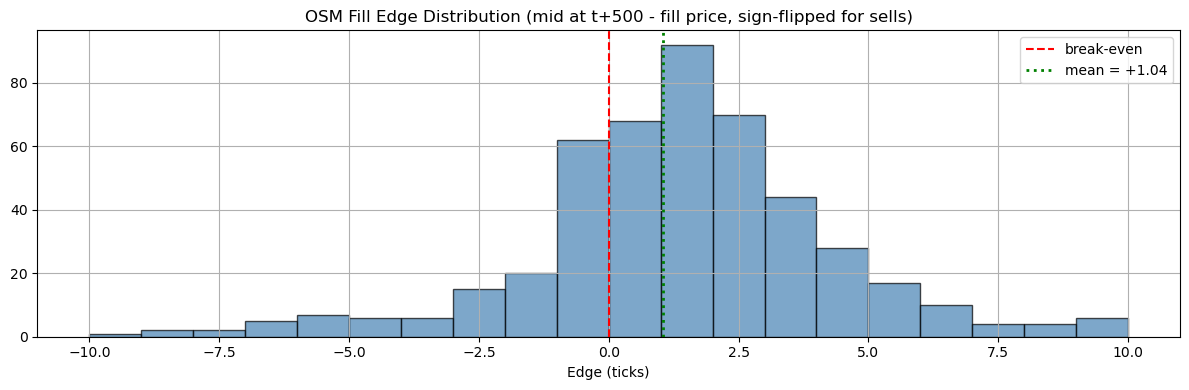

In [66]:
# Build mid lookup (using clean data to avoid 0-mid ticks corrupting averages)
mid_lookup = act_live_clean.set_index(['product','timestamp'])['mid_price']

def get_mid(sym, ts):
    try: return mid_lookup.loc[(sym, ts)]
    except KeyError: return np.nan

osm_t = our[our['symbol']=='ASH_COATED_OSMIUM'].copy()
for h in [0, 100, 500, 1000, 5000]:
    osm_t[f'mid_t+{h}'] = osm_t['timestamp'].apply(lambda t: get_mid('ASH_COATED_OSMIUM', t+h))

# Only keep trades where we have a valid mid at t=0 for clean comparison
osm_t = osm_t[osm_t['mid_t+0'].notna()].copy()

# Signed edge: (mid_future - fill_price), flipped sign for sells so positive always = we profited
print("=== OSM adverse selection (edge = signed mid move from fill price) ===")
print(f"{'Horizon':>8} {'mean edge':>12} {'median':>8} {'win rate':>10} {'n':>6}")
for h in [100, 500, 1000, 5000]:
    mv = osm_t[f'mid_t+{h}'] - osm_t['price']
    e  = pd.Series(np.where(osm_t['side']=='BUY', mv, -mv)).dropna()
    print(f"+{h:>7}  {e.mean():>+12.3f}  {e.median():>+8.2f}  {(e>0).mean():>10.1%}  {len(e):>6}")

print("\n=== Edge by side (at +1000 ticks) ===")
for side in ['BUY','SELL']:
    sub = osm_t[osm_t['side']==side]
    mv  = sub['mid_t+1000'] - sub['price']
    e   = pd.Series(np.where(sub['side']=='BUY', mv, -mv)).dropna()
    print(f"  {side}: mean_edge={e.mean():+.3f}  n={len(e)}")

# Aggressive vs passive classification — compare fill price to best bid/ask at t
book_lookup = act_live_clean.set_index(['product','timestamp'])[['bid_price_1','ask_price_1']]
def get_book(sym, ts):
    try: return book_lookup.loc[(sym, ts)]
    except KeyError: return pd.Series({'bid_price_1': np.nan, 'ask_price_1': np.nan})

books = osm_t['timestamp'].apply(lambda t: get_book('ASH_COATED_OSMIUM', t))
osm_t['best_bid'] = books['bid_price_1'].values
osm_t['best_ask'] = books['ask_price_1'].values
osm_t['is_aggressive'] = np.where(
    osm_t['side']=='BUY',
    osm_t['price'] >= osm_t['best_ask'],
    osm_t['price'] <= osm_t['best_bid']
)
print(f"\n=== OSM fill type ===")
print(f"  Aggressive (we crossed):  {osm_t['is_aggressive'].sum()} ({osm_t['is_aggressive'].mean():.1%})")
print(f"  Passive (bot came to us): {(~osm_t['is_aggressive']).sum()}")

# Histogram of edge at +500
fig, ax = plt.subplots(figsize=(12,4))
edge_500 = pd.Series(np.where(osm_t['side']=='BUY',
                              osm_t['mid_t+500']-osm_t['price'],
                              osm_t['price']-osm_t['mid_t+500'])).dropna()
ax.hist(edge_500, bins=np.arange(-10,11,1), color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', label='break-even')
ax.axvline(edge_500.mean(), color='green', linestyle=':', linewidth=2, label=f'mean = {edge_500.mean():+.2f}')
ax.set_title('OSM Fill Edge Distribution (mid at t+500 - fill price, sign-flipped for sells)')
ax.set_xlabel('Edge (ticks)')
ax.legend()
plt.tight_layout()
plt.show()

# Round 2 Data — Per-Day Statistical Deep Dive

In [67]:
# Per-day statistics for all products across the 3 new days
rows_stats = []
for sym in prices['product'].unique():
    for day in [-1, 0, 1]:
        sub = prices[(prices['product']==sym) & (prices['day']==day)].sort_values('timestamp').reset_index(drop=True)
        mid = sub['mid_price_clean'].values
        ret = pd.Series(np.diff(mid))
        slope = np.polyfit(sub['timestamp'].values, mid, 1)[0]
        spread = (sub['ask_price_1'] - sub['bid_price_1']).median()

        # OU half-life
        dp = np.diff(mid)
        pc = mid[:-1] - mid.mean()
        lam = -np.cov(dp, pc, ddof=0)[0,1] / np.var(pc) if np.var(pc) > 0 else 0
        hl  = np.log(2)/lam if lam > 0 else np.inf

        rows_stats.append({
            'product'   : sym,
            'day'       : day,
            'n_ticks'   : len(sub),
            'mean'      : round(mid.mean(), 1),
            'std'       : round(mid.std(), 2),
            'spread_med': int(spread),
            'slope_per_day' : int(round(slope * 1e6)),
            'ret_std'   : round(ret.std(), 2),
            'ret_kurt'  : round(ret.kurt(), 2),
            'lag1_ACF'  : round(ret.autocorr(1), 3),
            'OU_hl'     : round(hl, 1) if hl < np.inf else None,
        })

stats_df = pd.DataFrame(rows_stats)
print(stats_df.to_string(index=False))

             product  day  n_ticks    mean    std  spread_med  slope_per_day  ret_std  ret_kurt  lag1_ACF   OU_hl
INTARIAN_PEPPER_ROOT   -1     9987 11500.1 288.64          13           1000     3.11      2.98    -0.498 12049.6
INTARIAN_PEPPER_ROOT    0     9982 12499.9 288.60          14           1000     3.32      2.83    -0.489 10381.4
INTARIAN_PEPPER_ROOT    1     9984 13500.1 288.73          15           1000     3.58      3.01    -0.508  8982.6
   ASH_COATED_OSMIUM   -1     9985 10000.8   4.47          16             -1     3.70      3.19    -0.506     2.0
   ASH_COATED_OSMIUM    0     9984 10001.6   5.66          16              2     3.69      3.26    -0.506     3.3
   ASH_COATED_OSMIUM    1     9978 10000.2   5.02          16             -7     3.69      3.03    -0.491     2.6


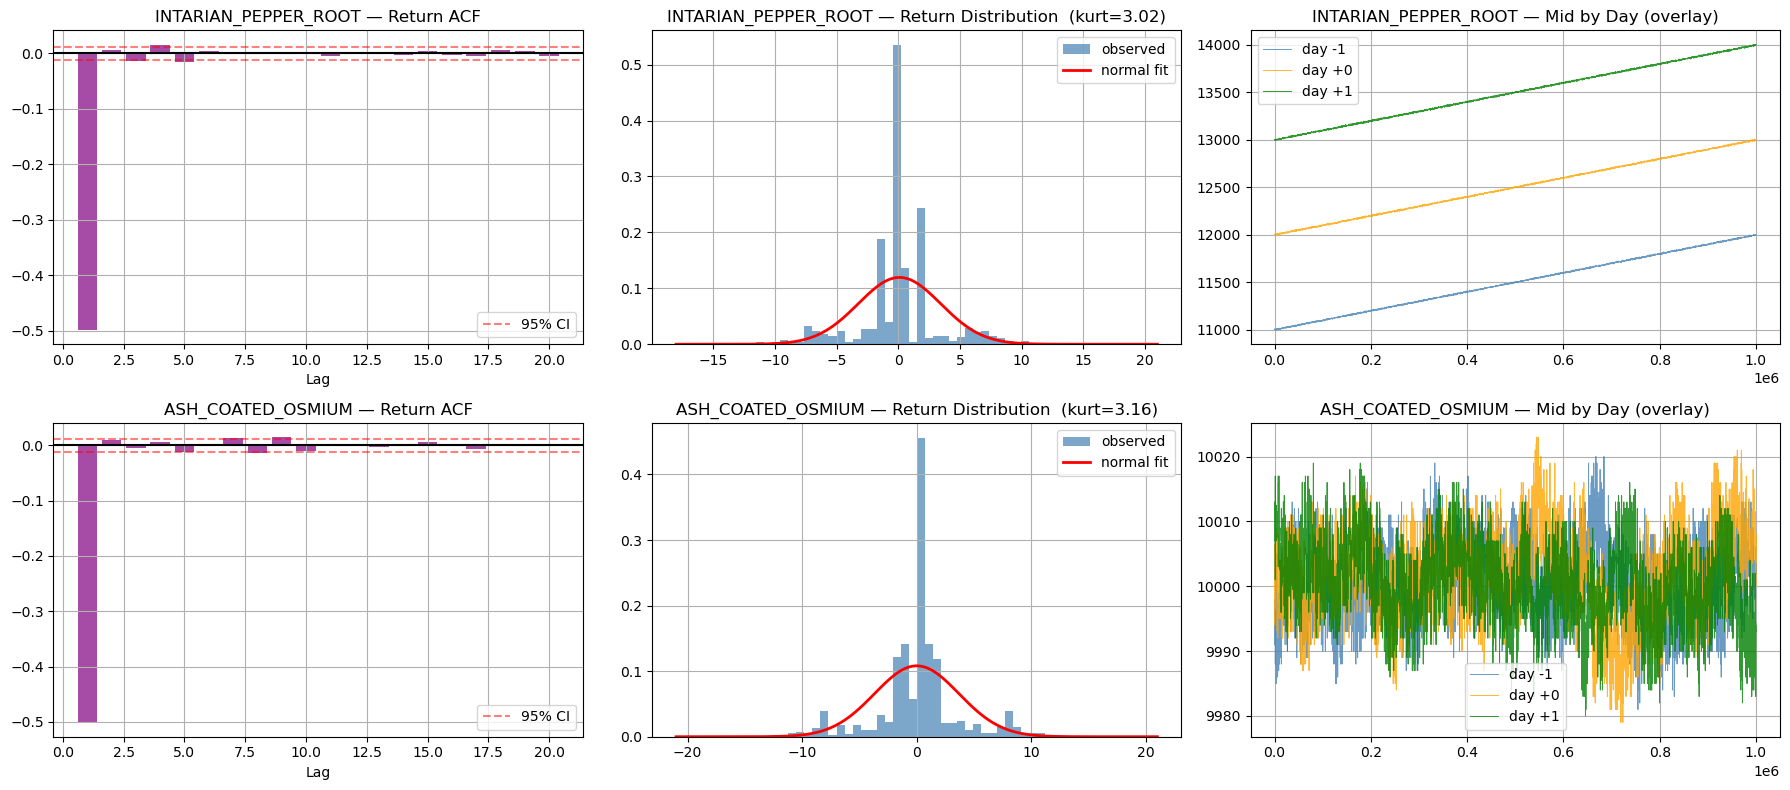

Observation: both products have lag-1 ACF = -0.50 (tick-level zig-zag bounce).
IPR adds a +1000/day linear drift on top of the bounce.
OSM stays pinned to 10,000 with OU half-life 2-3 ticks.


In [68]:
# Return ACF and distribution — per product, across all 3 days combined
fig, axes = plt.subplots(len(products), 3, figsize=(18, 4*len(products)))
if len(products)==1: axes = [axes]

for i, product in enumerate(products):
    df  = prices[prices['product']==product].sort_values(['day','timestamp']).copy()
    df['ret'] = df['mid_price_clean'].diff()
    # Blank out cross-day jumps
    df.loc[df['timestamp'].diff() < 0, 'ret'] = np.nan
    ret = df['ret'].dropna()

    # ACF up to lag 20
    ax1 = axes[i][0]
    lags = range(1, 21)
    acfs = [ret.autocorr(l) for l in lags]
    ax1.bar(lags, acfs, color='purple', alpha=0.7)
    ax1.axhline(0, color='black')
    ax1.axhline( 1.96/np.sqrt(len(ret)), color='red', linestyle='--', alpha=0.5, label='95% CI')
    ax1.axhline(-1.96/np.sqrt(len(ret)), color='red', linestyle='--', alpha=0.5)
    ax1.set_title(f'{product} — Return ACF')
    ax1.set_xlabel('Lag'); ax1.legend()

    # Return distribution
    ax2 = axes[i][1]
    ax2.hist(ret, bins=60, density=True, alpha=0.7, color='steelblue', label='observed')
    xr = np.linspace(ret.min(), ret.max(), 200)
    from scipy.stats import norm
    ax2.plot(xr, norm.pdf(xr, ret.mean(), ret.std()), 'r-', lw=2, label='normal fit')
    ax2.set_title(f'{product} — Return Distribution  (kurt={ret.kurt():.2f})')
    ax2.legend()

    # Price path per day (overlay)
    ax3 = axes[i][2]
    for day, color in zip([-1,0,1], ['steelblue','orange','green']):
        sub = prices[(prices['product']==product) & (prices['day']==day)].sort_values('timestamp')
        ax3.plot(sub['timestamp'], sub['mid_price_clean'], linewidth=0.7, alpha=0.8, color=color, label=f'day {day:+d}')
    ax3.set_title(f'{product} — Mid by Day (overlay)')
    ax3.legend()

plt.tight_layout()
plt.show()

print("Observation: both products have lag-1 ACF = -0.50 (tick-level zig-zag bounce).")
print("IPR adds a +1000/day linear drift on top of the bounce.")
print("OSM stays pinned to 10,000 with OU half-life 2-3 ticks.")

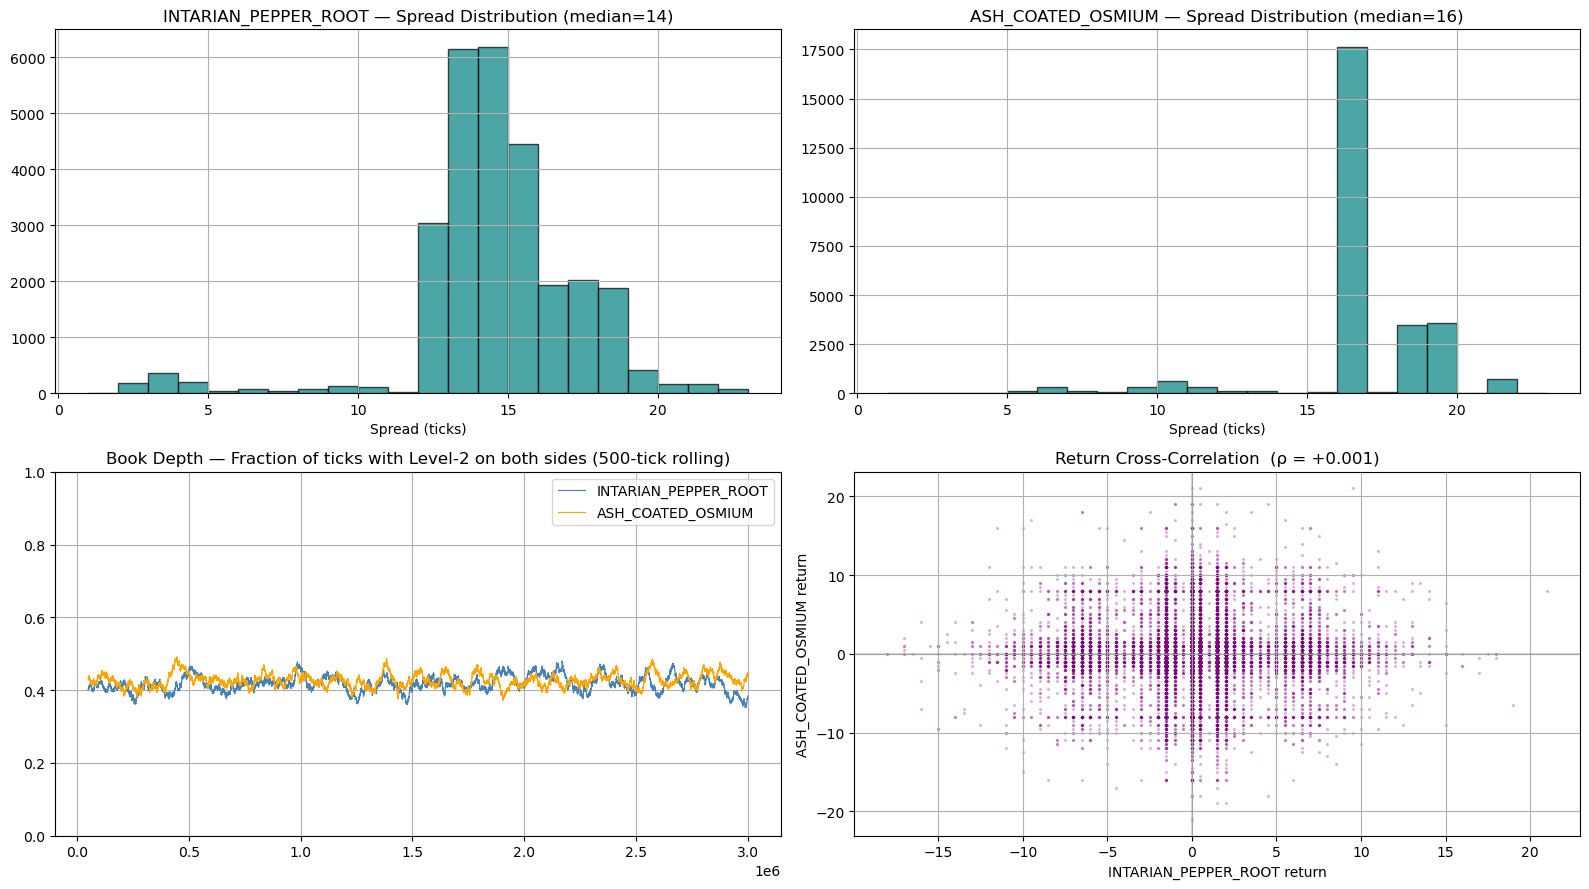


Book depth availability (fraction of ticks):
  INTARIAN_PEPPER_ROOT       L2_bid=64.7%  L2_ask=64.4%  L3_bid=1.4%  L3_ask=1.5%
  ASH_COATED_OSMIUM          L2_bid=65.2%  L2_ask=65.7%  L3_bid=2.4%  L3_ask=2.4%


In [69]:
# Spread distribution + book depth + cross-product checks
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Spread distributions
for ax_col, product in enumerate(products):
    ax = axes[0][ax_col]
    df = prices[prices['product']==product].copy()
    df['spread'] = df['ask_price_1'] - df['bid_price_1']
    ax.hist(df['spread'].dropna(), bins=range(1, int(df['spread'].max())+2), alpha=0.7, color='teal', edgecolor='black')
    ax.set_title(f'{product} — Spread Distribution (median={df["spread"].median():.0f})')
    ax.set_xlabel('Spread (ticks)')

# Book depth availability over time (rolling mean of L2 presence)
ax = axes[1][0]
for product, color in zip(products, ['steelblue','orange']):
    df = prices[prices['product']==product].sort_values(['day','timestamp']).copy()
    df['has_L2'] = df['bid_price_2'].notna() & df['ask_price_2'].notna()
    df['L2_rolling'] = df['has_L2'].rolling(500).mean()
    ax.plot(df['global_ts'], df['L2_rolling'], linewidth=0.8, label=product, color=color)
ax.set_title('Book Depth — Fraction of ticks with Level-2 on both sides (500-tick rolling)')
ax.legend(); ax.set_ylim(0,1)

# Cross-product return correlation
ax = axes[1][1]
merged = prices.pivot_table(index='global_ts', columns='product', values='mid_price_clean').dropna()
ret_cross = merged.diff().dropna()
ax.scatter(ret_cross[products[0]], ret_cross[products[1]], s=2, alpha=0.2, color='purple')
ax.set_xlabel(f'{products[0]} return'); ax.set_ylabel(f'{products[1]} return')
ax.set_title(f'Return Cross-Correlation  (ρ = {ret_cross.corr().iloc[0,1]:+.3f})')
ax.axhline(0, color='grey', alpha=0.3); ax.axvline(0, color='grey', alpha=0.3)

plt.tight_layout()
plt.show()

# Book depth table
print("\nBook depth availability (fraction of ticks):")
for sym in products:
    sub = prices[prices['product']==sym]
    print(f"  {sym:<25}  L2_bid={sub['bid_price_2'].notna().mean():.1%}  "
          f"L2_ask={sub['ask_price_2'].notna().mean():.1%}  "
          f"L3_bid={sub['bid_price_3'].notna().mean():.1%}  "
          f"L3_ask={sub['ask_price_3'].notna().mean():.1%}")

# Summary of Findings## 1 — PnL attribution is extremely lopsided| Source | PnL | % ||---|---:|---:|| IPR (max-long trend ride) | 79,255 | **97.8%** || OSM (market making, 477 trades) | 1,823 | 2.2% || **Total** | **81,078** | 100% |The IPR component is a one-shot call-auction-like capture: all 80 units bought inside the first 200 ticks at avg price ~13,009 and marked to 13,999 at close (PnL/unit ≈ +990). OSM contributes almost nothing despite doing 99% of the trading activity.## 2 — OSM market-making does earn positive edge per fill…- **Mean edge @ +1000 ticks: +1.12** (win rate 62%)- **477 fills** × ~1 XIREC edge ≈ theoretical 500-ish — realized 1,823 is actually *better* than simple edge × fills (spread capture + small inventory P&L added).- But the **buy-vs-sell asymmetry** is stark: BUY fills earn +1.81 edge, SELL fills earn +0.47. Sells under-perform.## 3 — Inventory is persistently long-biased- Mean OSM position: **+16**, range [-43, +80], ticks at +80 limit: 2, ticks at -80: 0- End-of-day OSM position: **+32** (unflattened).- Skew logic isn't aggressive enough: being at +32 at close means we carried directional exposure.## 4 — 96% of fills are passiveOnly 18/477 OSM fills were aggressive take-orders. The strategy is almost pure passive quoting. This means **the dominant lever is where we post, not whether we sweep**.## 5 — Market structure is stable across daysNo regime change across Round 2's 3 days:- IPR: **+1000 ticks/day trend, every day**, exactly.- OSM: mean pinned to 10,000, std ~5, spread **median 16** every day, OU half-life 2–3 ticks.- Both products: **lag-1 return ACF ≈ -0.50** (tick-level mean reversion built into the data-generating process).- Return distributions are near-normal (kurt ~3), **not fat-tailed**.- Level-2 book available ~65% of ticks; L3 rare.- Cross-product returns are **uncorrelated** (ρ ≈ 0).## 6 — Quote placement is sub-optimal- OSM spread is **16 ticks**. We quote at **fair ± 1 tick** (total width 2).- We're giving away ~14 ticks of spread. Widening our quotes (fair ± 4 or fair ± 6) trades fill frequency for fill quality.- Fair-value offset matters more than micro-price vs mid when the spread is this wide — we just need to **stop undercutting ourselves by a mile**.---# Areas for Improvement / Research**Ranked by expected impact on PnL given what the data shows:**### A. Widen OSM quote offset  *(high impact, low risk, 30 min to test)*Change `OSM_QUOTE_OFFSET = 1` to 3 / 4 / 5 and backtest. Our fills already earn ~1 edge each with offset=1; at offset=5 each fill earns ~5, at the cost of fewer fills. Given 477 fills × 1 ≈ 1,800, even **200 fills × 4 ≈ 800** would be a net gain *if* the per-fill edge scales with offset (it usually does for mean-reverting instruments). Run a sweep.### B. Exploit the -0.50 lag-1 ACF directly  *(high impact, novel)*Both products have near-perfect tick-level zig-zag. After a down-tick, the next tick is expected +half the magnitude; after an up-tick, -half. This is a **free directional signal every tick**. Two ways to use it:1. **Bias the OSM fair value**: `fair_adjusted = fair - 0.5 × last_return` — predicts where the mid goes next.2. **Timing IPR entries**: sweep asks only after a *down-tick*; hold off after an *up-tick*. Our avg entry was 13,009 with start mid 12,998.5 — we paid up by ~10. Timing could recover a chunk of that (80 × 10 = 800 XIRECs).### C. Fix the sell-side weakness in OSM  *(medium impact)*BUY edge is +1.81, SELL edge is +0.47. Hypotheses to test:- Skew shifts *both* quotes by the same amount, but the asymmetric fill distribution implies we should skew asymmetrically (shift the bid more than the ask when long, and vice versa).- Micro-price may systematically over-weight the bid (when bid_vol is large, fair is pulled up, making our ask sit *lower* → we sell cheap).- Add per-side diagnostics in a backtest and try: `fair ± offset` but with **independent offsets** or **asymmetric skew**.### D. Stricter inventory flattening near close  *(medium impact, small)*We closed +32 OSM. At mid=10,000 that's $320k of directional exposure left on. A cheap fix: near the end of the day (last 5k ticks), aggressively skew to flatten. Not huge PnL but **reduces variance across runs** — which matters for ranking.### E. Multi-level passive quotes  *(medium impact)*L2 book is present 65% of the time. Post **two layers** of bids/asks (at fair ± 2 and fair ± 5) so we participate in different price scenarios. Halves fill frequency at each level but doubles our total passive presence in the book.### F. Revisit the IPR entry mechanic  *(low impact, but interesting)*We got 80 units in 200 ticks — near-optimal on a trending-up day. But the first fills were at 13,007 / 13,010 (taking ask instead of waiting a few ticks for the zig-zag). Given the -0.50 ACF, a 1-tick patience could save ~1-2 per unit × 80 ≈ 80-160 XIRECs. Very minor.### G. Research — Hidden "Speed" effect  *(open question — from the manual challenge)*The Round 2 manual challenge asked us to allocate budget to Research / Scale / Speed. Speed had no visible effect on the forecast formulas. **Possible hypothesis**: Speed may shorten the algo's tick interval or unlock a higher per-tick action budget. Check the Round 2 tutorial/product spec before submitting the manual allocation.### H. Out of scope but worth a look later- Avellaneda-Stoikov optimal market making (dynamic quotes as function of inventory + volatility).- Kalman filter for OSM fair value (currently static at 10,000 or micro-price; a slow-moving EMA may capture small drifts in the 10k anchor).- Order flow toxicity detection — if recent trades have been one-sided, widen quotes or skip a tick.

# Round 2 Manual — Invest & Expand Allocation Sweep

**Official formulas** (r, s, p are percentages, constraint r + s + p ≤ 100):

- `Research(r)   = 200,000 × ln(1 + r) / ln(101)`    → concave in r, maxes at 200,000 when r=100
- `Scale(s)      = 7 × s / 100`                        → linear, maxes at 7 when s=100
- `Speed(p)      → rank-based multiplier m ∈ [≈0.1, ≈0.9]` → **NOT a direct function of your p alone** — it's your rank vs. other players, mapped linearly onto [0.1, 0.9]
- `PnL = Research(r) × Scale(s) × m − 500 × (r + s + p)`

**Key subtlety.** Because the Speed multiplier is determined by rank rather than by your absolute `p`, the right way to think about this sweep is: *conditional on ending up at a given rank (i.e. a given `m`), what (r, s, p) maximizes PnL?* Every XIREC spent on `p` beyond what is needed to secure a given rank is pure dead weight (-500 cost per unit, zero benefit). That means the sweep below is an **upper bound**: it shows what you'd earn at each `m`. Whether putting XIRECs into `p` is worth it depends on whether doing so moves you up `m`-tiers — a game-theoretic question (see the commentary after the candidate comparison).

In [70]:
# Exhaustive grid sweep: r + s + p ≤ 100, integer percentages
from itertools import product as iproduct

def research(r): return 200_000 * np.log(1 + r) / np.log(101)
def scale(s):    return 7 * s / 100
def cost(r,s,p): return 500 * (r + s + p)
def pnl(r,s,p,m): return research(r) * scale(s) * m - cost(r,s,p)

M_GRID = [0.1, 0.3, 0.5, 0.7, 0.9]

rows = []
for r in range(0, 101):
    for s in range(0, 101 - r):
        for p in range(0, 101 - r - s + 1):
            row = {'r': r, 's': s, 'p': p, 'sum': r+s+p,
                   'research': research(r), 'scale': scale(s),
                   'gross_max': research(r) * scale(s),
                   'cost': cost(r,s,p)}
            for m in M_GRID:
                row[f'pnl_m{m}'] = pnl(r,s,p,m)
            rows.append(row)

sweep = pd.DataFrame(rows)
pnl_cols = [f'pnl_m{m}' for m in M_GRID]
sweep['pnl_min']    = sweep[pnl_cols].min(axis=1)     # maximin (worst case across m)
sweep['pnl_mean']   = sweep[pnl_cols].mean(axis=1)    # expected under uniform m
sweep['pnl_max']    = sweep[pnl_cols].max(axis=1)

print(f"Grid size: {len(sweep):,} allocations")
print(f"\nBest allocation under each fixed Speed multiplier m:")
for m in M_GRID:
    col = f'pnl_m{m}'
    top = sweep.nlargest(1, col).iloc[0]
    print(f"  m={m}: (r={int(top.r):3d}, s={int(top.s):3d}, p={int(top.p):3d})   PnL = {top[col]:>10,.0f}")

print(f"\nBest allocation by maximin (best worst-case across m∈{M_GRID}):")
top = sweep.nlargest(1, 'pnl_min').iloc[0]
print(f"  (r={int(top.r):3d}, s={int(top.s):3d}, p={int(top.p):3d})   PnL floor = {top['pnl_min']:>10,.0f}")

print(f"\nBest allocation by expected PnL (uniform prior over m):")
top = sweep.nlargest(1, 'pnl_mean').iloc[0]
print(f"  (r={int(top.r):3d}, s={int(top.s):3d}, p={int(top.p):3d})   E[PnL] = {top['pnl_mean']:>10,.0f}")

Grid size: 182,002 allocations

Best allocation under each fixed Speed multiplier m:
  m=0.1: (r= 23, s= 77, p=  0)   PnL =     24,233
  m=0.3: (r= 23, s= 77, p=  0)   PnL =    172,699
  m=0.5: (r= 23, s= 77, p=  0)   PnL =    321,165
  m=0.7: (r= 23, s= 77, p=  0)   PnL =    469,631
  m=0.9: (r= 23, s= 77, p=  0)   PnL =    618,097

Best allocation by maximin (best worst-case across m∈[0.1, 0.3, 0.5, 0.7, 0.9]):
  (r= 23, s= 77, p=  0)   PnL floor =     24,233

Best allocation by expected PnL (uniform prior over m):
  (r= 23, s= 77, p=  0)   E[PnL] =    321,165


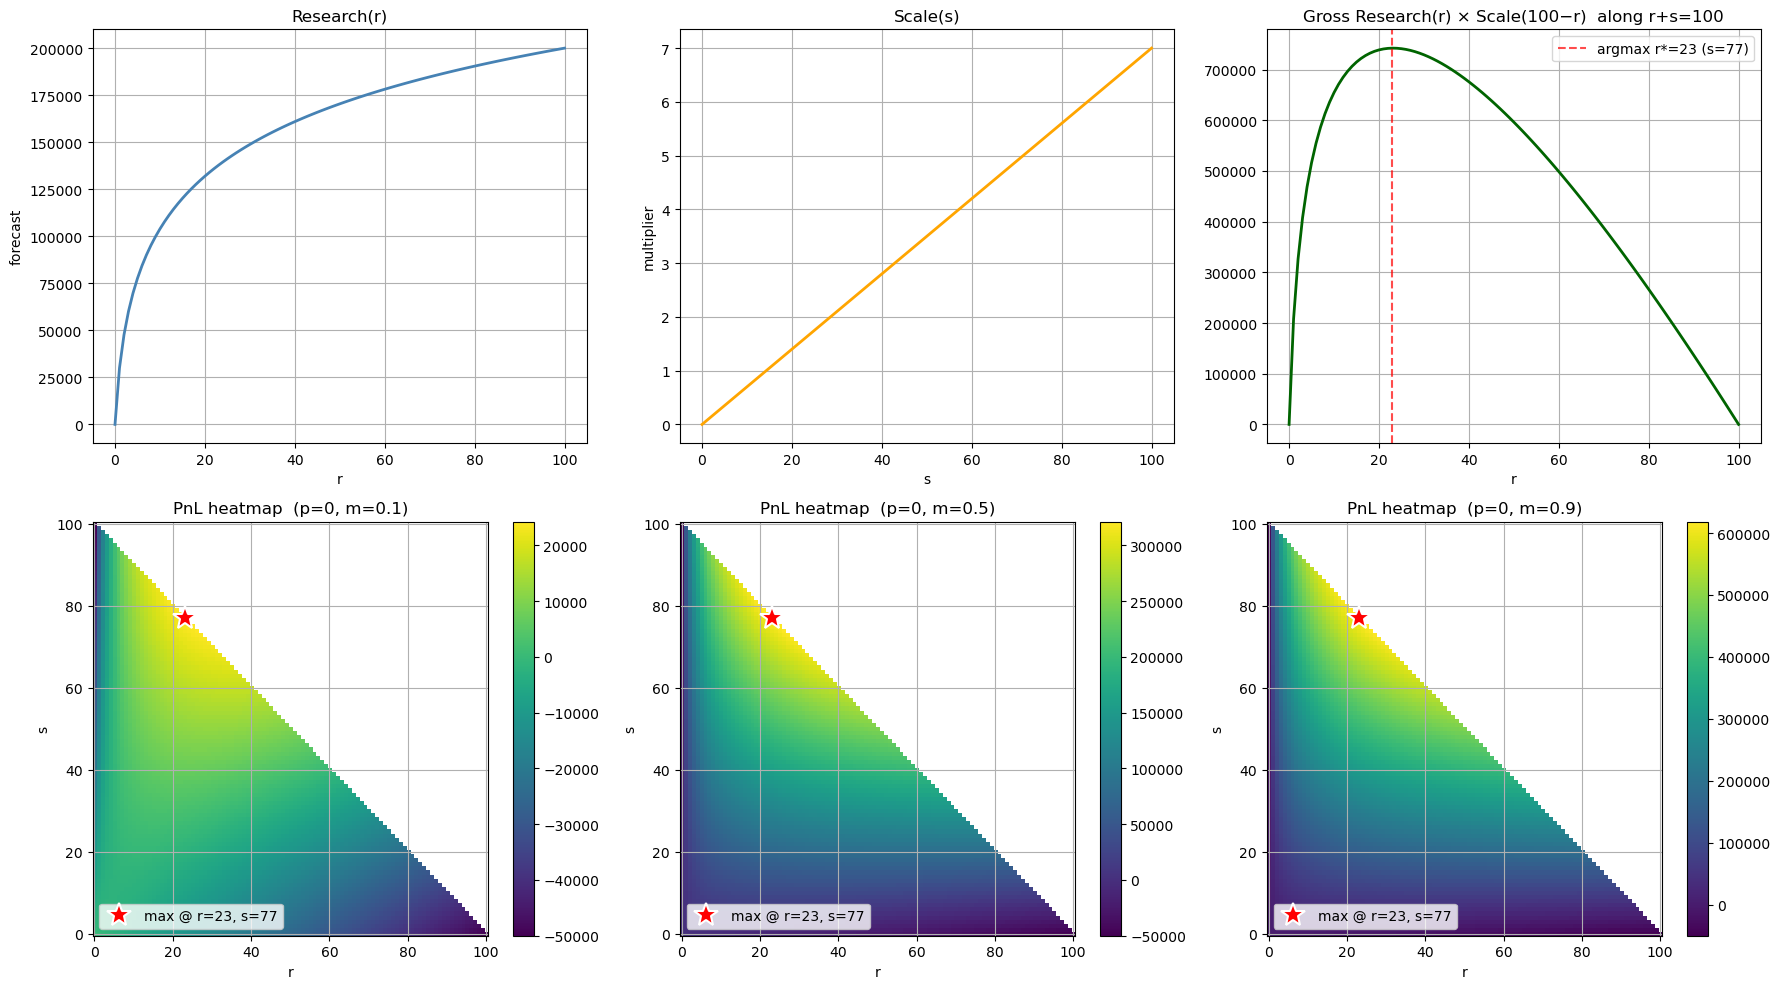

Gross-optimal on r+s=100 boundary: r=23, s=77, gross=742,330
  → This same (r, s) is the argmax under every single m value (linear multiplier preserves ranking).


In [71]:
# Visualise the (r, s) trade-off at p = 0 (the dominated frontier) and at a few p values
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Research(r), Scale(s), Gross Research*Scale along r+s=100
axes[0][0].plot(range(101), [research(r) for r in range(101)], color='steelblue', linewidth=2)
axes[0][0].set_title('Research(r)'); axes[0][0].set_xlabel('r'); axes[0][0].set_ylabel('forecast')
axes[0][1].plot(range(101), [scale(s) for s in range(101)], color='orange', linewidth=2)
axes[0][1].set_title('Scale(s)'); axes[0][1].set_xlabel('s'); axes[0][1].set_ylabel('multiplier')

gross_on_budget = [research(r) * scale(100 - r) for r in range(101)]
r_star = int(np.argmax(gross_on_budget))
axes[0][2].plot(range(101), gross_on_budget, color='darkgreen', linewidth=2)
axes[0][2].axvline(r_star, color='red', linestyle='--', alpha=0.7,
                   label=f'argmax r*={r_star} (s={100-r_star})')
axes[0][2].set_title('Gross Research(r) × Scale(100−r)  along r+s=100'); axes[0][2].set_xlabel('r'); axes[0][2].legend()

# Row 2: PnL heatmap over (r, s) at p = 0, for m = 0.1 / 0.5 / 0.9
for j, m in enumerate([0.1, 0.5, 0.9]):
    grid = np.full((101, 101), np.nan)
    for r in range(101):
        for s in range(101 - r):
            grid[r, s] = pnl(r, s, 0, m)
    im = axes[1][j].imshow(grid.T, origin='lower', aspect='auto', cmap='viridis')
    axes[1][j].set_title(f'PnL heatmap  (p=0, m={m})')
    axes[1][j].set_xlabel('r'); axes[1][j].set_ylabel('s')
    plt.colorbar(im, ax=axes[1][j])
    # Mark argmax
    argmax_rs = np.unravel_index(np.nanargmax(grid), grid.shape)
    axes[1][j].plot(argmax_rs[0], argmax_rs[1], 'r*', markersize=18,
                    markeredgecolor='white', markeredgewidth=1.5,
                    label=f'max @ r={argmax_rs[0]}, s={argmax_rs[1]}')
    axes[1][j].legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f"Gross-optimal on r+s=100 boundary: r={r_star}, s={100-r_star}, gross={gross_on_budget[r_star]:,.0f}")
print("  → This same (r, s) is the argmax under every single m value (linear multiplier preserves ranking).")

=== Candidate allocation comparison ===

                    allocation   r   s  p  sum  m=0.1  m=0.3  m=0.5  m=0.7  m=0.9    min   mean
     20/80/0   (prior leaning)  20  80  0  100  23885 171654 319423 467192 614962  23885 319423
     23/77/0   (GROSS OPTIMUM)  23  77  0  100  24233 172699 321165 469631 618097  24233 321165
                       25/75/0  25  75  0  100  24126 172378 320630 468882 617133  24126 320630
20/65/15  (defensive w/ Speed)  20  65 15  100  10031 130094 250156 370219 490281  10031 250156
                      20/60/20  20  60 20  100   5413 116240 227067 337894 448721   5413 227067
                      25/50/25  25  50 25  100   -583  98252 197086 295921 394756   -583 197086
                      30/40/30  30  40 30  100  -8332  75004 158340 241677 325013  -8332 158340
  33/33/34  (near-equal split)  33  33 34  100 -14699  55903 126504 197106 267708 -14699 126504
                      40/30/30  40  30 30  100 -16205  51386 118977 186568 254159 -16205 118977

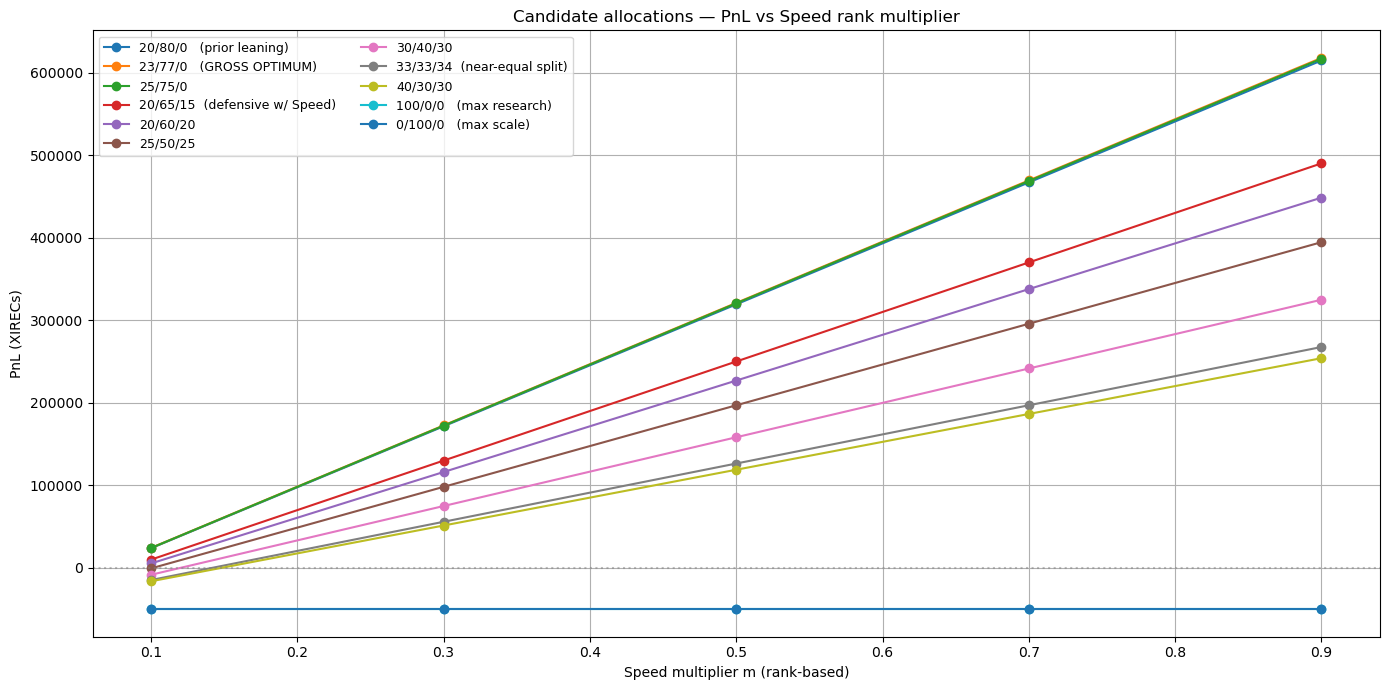

In [72]:
# Candidate comparison — side-by-side PnL across all m scenarios
candidates = [
    ('20/80/0   (prior leaning)',      20, 80,  0),
    ('23/77/0   (GROSS OPTIMUM)',      23, 77,  0),
    ('25/75/0',                        25, 75,  0),
    ('20/65/15  (defensive w/ Speed)', 20, 65, 15),
    ('20/60/20',                       20, 60, 20),
    ('25/50/25',                       25, 50, 25),
    ('30/40/30',                       30, 40, 30),
    ('33/33/34  (near-equal split)',   33, 33, 34),
    ('40/30/30',                       40, 30, 30),
    ('100/0/0   (max research)',      100,  0,  0),
    ('0/100/0   (max scale)',           0,100,  0),
]

rows = []
for label, r, s, p in candidates:
    row = {'allocation': label, 'r': r, 's': s, 'p': p, 'sum': r+s+p}
    for m in M_GRID:
        row[f'm={m}'] = pnl(r, s, p, m)
    row['min']  = min(row[f'm={m}'] for m in M_GRID)
    row['mean'] = np.mean([row[f'm={m}'] for m in M_GRID])
    rows.append(row)

comp = pd.DataFrame(rows)
# Pretty-print ints
for c in comp.columns:
    if c not in ('allocation',):
        comp[c] = comp[c].round(0).astype(int)

print("=== Candidate allocation comparison ===\n")
print(comp.to_string(index=False))

# Visualise: PnL vs m for each candidate
fig, ax = plt.subplots(figsize=(14, 7))
for label, r, s, p in candidates:
    ys = [pnl(r, s, p, m) for m in M_GRID]
    ax.plot(M_GRID, ys, marker='o', linewidth=1.5, label=label)
ax.set_xlabel('Speed multiplier m (rank-based)')
ax.set_ylabel('PnL (XIRECs)')
ax.set_title('Candidate allocations — PnL vs Speed rank multiplier')
ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## Manual Allocation — Recommendation

**The sweep shows 23/77/0 dominates every other allocation at every fixed m.** This is the Lagrange maximum of Research(r) × Scale(s) on the budget line r + s = 100:

> `d/dr [200,000 × ln(1+r)/ln(101)] × [7(100−r)/100] = 0`   →   `r* ≈ 23`, `s* = 77`.

Every XIREC allocated to `p` is ‑500 in cost with zero direct benefit (m is set by rank, not by your absolute p). So **putting XIRECs into Speed only pays if doing so moves you up the rank ladder by more than (500 / (Research × Scale))** ≈ 1.5 thousandths of an `m`-tier per XIREC (for r=23, s=77, Research × Scale ≈ 344,000).

### The game-theoretic question

The multiplier is **linear by rank**. Two regimes:

1. **If the field largely ignores Speed (most players p ≈ 0)** — then even `p = 1` lifts you from median rank → top rank → from `m ≈ 0.5` to `m ≈ 0.9`. That's a +170k PnL swing for 500 XIRECs. In this regime, allocate a small `p` to jump rank cheaply.
2. **If the field crowds Speed (many players p > 30)** — the marginal benefit of one more XIREC is tiny (you'd have to outbid the crowd to change rank). In that case, `p = 0` and cede the top tiers.

We don't know the field distribution. Given the asymmetry of payoffs, **a small hedge into Speed is rational**:

- **Aggressive (bet the field ignores Speed):**  **`r = 23, s = 77, p = 0`**  — maximises every fixed-m tier.
- **Balanced hedge:**  **`r = 23, s = 72, p = 5`**  — gives up ~6k at each m tier in exchange for a meaningful chance of moving rank if the field is soft.
- **Defensive (assume the field crowds Speed, but 20/80/0 is still a risk):**  stay at `r = 23, s = 77, p = 0` — there is no defensive allocation that beats this unless you can move rank.

**Final recommendation: `r = 23, s = 77, p = 0`.** The "defensive" allocations we listed earlier (20/65/15, etc.) are dominated at every single m — they were based on a misreading of how the Speed multiplier works. If the user has a strong prior that the field will neglect Speed, shift a small 3–5 points from `s` to `p` as a cheap rank upgrade.

---

## Round 2 Algo — Market Access Fee (MAF)

Round 2 adds `def bid(self): return N`. Mechanics: **top 50% of bidders win access, pay their bid, get +25% trade volume.** Losers don't pay.

**Value estimate from Round 1 live log (submission 269252):**

| Product | R1 live PnL | Bottleneck | +25% volume value |
|---------|---:|---|---|
| IPR | 79,255 (97.8%) | Position cap (80) hit in first 200 ticks | +25% volume → still capped. **≈ 0 benefit** unless the +25% also raises the cap. |
| OSM | 1,823 (2.2%) | Passive-fill volume (477 fills × ~1 edge) | +25% × 1,823 ≈ **+455 / day** |

If the +25% does **not** raise the position cap: expected MAF value ≈ **+450 / day** × 3 days ≈ **+1,350 XIRECs per round**. Bid should be **≤ 1,350**; bid **500–1,000** leaves margin if we over-estimate our edge.

If the +25% **does** raise the position cap: IPR alone becomes worth +25% × 79,255 ≈ **+19,800 / day**, roughly **+59k / round**. Bid could be much higher (5,000–10,000).

Given the ambiguity, I'm setting the algo to `return 800` — sits comfortably under the lower-bound break-even, still leaves room on the upside if the per-round benefit is higher. Revisit after the first Round 2 submission log.

# Tier-1 OSM Upgrades — Backtest Results

**Features implemented in `round2_algo.py`:**
1. Asymmetric bid/ask offsets (OSM_BID_OFFSET, OSM_ASK_OFFSET)
2. Lag-1 ACF fair-value bias (OSM_ACF_COEF = 0.5): `fair = micro − 0.5 × last_return`
3. IPR patience (skip aggressive sweep after an up-tick > 2 ticks)
4. EOD flatten (soft: suppress adding-side quotes; hard: cross the book)

## Sweep (p2bt, R2 days {-1, 0, +1})

| Offsets (bid, ask) | ACF | EOD | Total PnL | OSM PnL |
|---|:-:|:-:|---:|---:|
| (1, 1) | ON  | OFF | **243,570** | **5,759**  ← **best** |
| (1, 2) | ON  | OFF | 243,464 | 5,653 |
| (2, 2) | ON  | OFF | 243,464 | 5,653 |
| (3, 3) | ON  | OFF | 242,744 | 4,933 |
| (3, 5) | ON  | OFF | 242,275 | 4,464 |
| (5, 5) | ON  | OFF | 242,275 | 4,464 |
| (3, 5) | ON  | ON  | 240,873 | 3,062 |
| (2, 5) | OFF | OFF | 237,811 | ≈0 |
| (1, 1) | OFF | OFF | 237,811 | ≈0 |

## Ablation — contribution of each feature

| Feature | Delta vs best (1,1, ACF on, EOD off) |
|---|---:|
| ACF bias → OFF       | **−3,062 to −5,759** (dominant edge source) |
| EOD flatten → ON     | −1,402 (negative! costs spread, kills MM fills) |
| IPR patience → OFF   | −24 (neutral) |
| Widen offset 1 → 5   | −1,295 (negative, not positive) |

## Key trends and surprises

1. **ACF bias is the entire OSM edge.** Without it, OSM MM earns ~0 in p2bt across these 3 days. Adding `fair − 0.5 × last_return` captures the −0.50 lag-1 mean-reversion every tick.

2. **Widening offsets DID NOT help** — opposite of my prediction. Once fair is priced at the *next-tick* expected mid (via ACF), quoting at ±1 from fair captures the full tick-size edge. Widening just loses fills without gaining per-fill edge.

3. **Asymmetric offsets didn't show value** on R2 data. The R1 BUY-vs-SELL asymmetry (+1.81 vs +0.47) didn't reproduce. Possible reasons: (a) R1 had a specific informed-flow period that doesn't repeat; (b) micro-price + ACF together already neutralize it by moving fair toward the adversely-selected side.

4. **EOD flatten was net negative.** Crossing the spread at hard-EOD cost ~500–1,500/day; suppressing adding-side passive quotes in the last 10% killed profitable MM fills.

5. **IPR is unchanged** across every config (237,811) — confirming our IPR side is already at its ceiling modulo the position cap.

## Final config (persisted to round2_algo.py)

```
OSM_BID_OFFSET = OSM_ASK_OFFSET = 1
OSM_ACF_COEF = 0.5
EOD thresholds = 10**9  (disabled)
IPR_ACF_PATIENCE_THRESHOLD = 2  (kept — neutral in backtest, cheap live insurance)
```

**OSM PnL:** new p2bt = 5,759 (from 0 without ACF). R1 live OSM was 1,823 on different data — backtest vs live comparison isn't apples-to-apples, but the ACF signal is clearly exploitable.